<a href="https://colab.research.google.com/github/nemiys/Project-3---Airbnb-Dublin-/blob/main/AirbnbDablin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div dir="rtl">

# פרויקט ניתוח נתוני Airbnb דבלין
במחברת זו נבצע ניתוח מעמיק (EDA) על נתוני חיפושים ומגעים בין אורחים למארחים. המטרה היא לזהות דפוסי התנהגות, אחוזי המרה ותובנות עסקיות.

</div>

<div dir="rtl">

## שלב 1: ייבוא ספריות והגדרות תצוגה
בשלב זה נטען את כל הכלים הדרושים לעיבוד הנתונים וויזואליזציה.

</div>

In [1]:
# ספריות לניהול ועיבוד טבלאות נתונים
import pandas as pd
import numpy as np

# ספריות ליצירת גרפים וויזואליזציות
import matplotlib.pyplot as plt
import seaborn as sns

# הגדרות תצוגה
%matplotlib inline
pd.options.display.float_format = '{:.2f}'.format # הצגת מספרים עם 2 ספרות אחרי הנקודה
sns.set_theme(style="whitegrid") # עיצוב גרפים נקי

print("הספריות נטענו בהצלחה!")

הספריות נטענו בהצלחה!


<div dir="rtl">

## שלב 2: חיבור ל-Google Drive וטעינת הנתונים
כדי לשמור על רציפות העבודה, נחבר את המחברת ישירות ל-Google Drive ונטען את קבצי המקור.

</div>

In [2]:
import pandas as pd

# הגדרת נתיבי ה-Raw מגיטהאב
path_contacts = 'https://github.com/nemiys/Project-3---Airbnb-Dublin-/raw/refs/heads/main/contacts_fixed.xlsx'
path_searches = 'https://github.com/nemiys/Project-3---Airbnb-Dublin-/raw/refs/heads/main/searches_fixed.xlsx'

try:
    # טעינת הקבצים ישירות מהרשת
    df_contacts = pd.read_excel(path_contacts)
    df_searches = pd.read_excel(path_searches)

    print("--- סטטוס טעינה מ-GitHub ---")
    print(f"טבלת Contacts נטענה: {df_contacts.shape[0]} שורות")
    print(f"טבלת Searches נטענה: {df_searches.shape[0]} שורות")

except Exception as e:
    print(f"שגיאה בטעינת הקבצים מגיטהאב. וודא שהקישורים תקינים. הודעת השגיאה: {e}")

# הצצה לנתוני החיפושים
df_searches.head()

--- סטטוס טעינה מ-GitHub ---
טבלת Contacts נטענה: 7823 שורות
טבלת Searches נטענה: 35737 שורות


,ds,id_user,ds_checkin,ds_checkout,date_check,n_searches,n_nights,stay_category,n_guests_min,n_guests_max,origin_country,filter_price_min,filter_price_max,uses_price_filter,filter_room_types_corrected,uses_room_filter,filter_neighborhoods,search_lead_time,lead_time_category
0,2014-10-01,0000af0a-6f26-4233-9832-27efbfb36148,2014-10-09,2014-10-12,OK,16,3.00,1-3 Nights (Weekend/Short),2,2,IE,0.00,67.00,1,"['Private room', 'Entire home/apt']",1,NaN,8,8-30 Days (Short Term)
1,2014-10-01,0000af0a-6f26-4233-9832-27efbfb36148,2014-10-09,2014-10-19,OK,3,10.00,7-27 Nights (Extended Stay),1,2,IE,0.00,67.00,1,NaN,0,NaN,8,8-30 Days (Short Term)
2,2014-10-01,000cd9d3-e05b-4016-9e09-34a6f8ba2fc5,NaT,NaT,Missing Dates,1,NaN,No Dates Provided,1,1,GB,NaN,NaN,0,NaN,0,NaN,No Date,No Date
3,2014-10-01,000cd9d3-e05b-4016-9e09-34a6f8ba2fc5,2014-11-08,2014-11-10,OK,11,2.00,1-3 Nights (Weekend/Short),1,2,GB,NaN,NaN,0,['Entire home/apt'],1,NaN,38,31-90 Days (Medium Term)
4,2014-10-01,001c04f0-5a94-4ee0-bf5d-3591265256de,NaT,NaT,Missing Dates,1,NaN,No Dates Provided,1,1,IE,NaN,NaN,0,NaN,0,NaN,No Date,No Date


<div dir="rtl">

## שלב 3: בדיקת סוגי נתונים ואיכות המידע (Data Info & Quality)
בשלב זה נוודא שפייתון מזהה נכון את סוגי העמודות (תאריכים כ-Datetime, מספרים כ-Int/Float ומזהים כ-String). כמו כן, נבדוק האם קיימים ערכים חסרים (Missing Values) שעלולים להשפיע על המיזוג.

</div>

In [3]:
# בדיקת סוגי הנתונים וערכים חסרים בטבלת החיפושים
print("--- מידע על טבלת Searches ---")
print(df_searches.info())

print("\n" + "="*50 + "\n")

# בדיקת סוגי הנתונים וערכים חסרים בטבלת המגעים
print("--- מידע על טבלת Contacts ---")
print(df_contacts.info())

# בדיקת כמות ערכים חסרים בכל עמודה
print("\n--- ערכים חסרים ב-Searches ---")
print(df_searches.isnull().sum())

--- מידע על טבלת Searches ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35737 entries, 0 to 35736
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   ds                           35737 non-null  datetime64[ns]
 1   id_user                      35737 non-null  object        
 2   ds_checkin                   23888 non-null  datetime64[ns]
 3   ds_checkout                  23888 non-null  datetime64[ns]
 4   date_check                   35737 non-null  object        
 5   n_searches                   35737 non-null  int64         
 6   n_nights                     23888 non-null  float64       
 7   stay_category                35737 non-null  object        
 8   n_guests_min                 35737 non-null  int64         
 9   n_guests_max                 35737 non-null  int64         
 10  origin_country               35737 non-null  object        
 11  filter_pric

<div dir="rtl">

### **🔍 בדיקות איכות נתונים**

הקוד מבצע בדיקות לוגיות לאיתור נתונים פגומים:

* **היגיון אורחים:** מוודא שמינימום האורחים אינו עולה על המקסימום.
* **סנכרון תאריכים:** בודק שמשך השהייה תואם להפרש בין ה-Check-in ל-Check-out.
* **זמן תגובה:** מוודא שאין ערכים שליליים בזמן התגובה (שגיאת מערכת).

**המטרה:** קבלת ערך `0` בכל הבדיקות, המעיד על נתונים תקינים.

</div>

In [4]:
print("=== DATA QUALITY CHECKS ===")

print("\n1. Guests logic check (min > max):")
print((df_searches['n_guests_min'] > df_searches['n_guests_max']).sum())

print("\n2. Length of stay vs dates mismatch:")
print((df_contacts['length_of_stay'] !=
       (df_contacts['ds_checkout'] - df_contacts['ds_checkin']).dt.days).sum())

print("\n3. Negative reply times:")
print((df_contacts['reply_time_minutes'] < 0).sum())

=== DATA QUALITY CHECKS ===

1. Guests logic check (min > max):
0

2. Length of stay vs dates mismatch:
0

3. Negative reply times:
0


<div dir="rtl">

## 1. ניתוח משפך ההמרה הכללי (The Overall Conversion Funnel)
**מטרה:** להבין את יעילות התהליך בדבלין במהלך חודש אוקטובר – מהחיפוש הראשוני ועד לביצוע הזמנה סגורה.

**הגדרות המדדים:**
* **Search to Contact (Conversion Rate):** אחוז המשתמשים הייחודיים שביצעו לפחות חיפוש אחד ועברו לשלב יצירת קשר עם מארח.
* **Contact to Booking (Close Rate):** אחוז הפניות (Inquiries) שהבשילו לכדי הזמנה מאושרת ומשולמת.

**ממצאים מרכזיים:**
* **המרה לשיחה:** 15.79% - מעיד על עניין גבוה אך סלקטיבי בשוק דבלין.
* **המרה להזמנה:** 32.9% - כשליש מהפניות מסתיימות בעסקה, נתון חיובי המעיד על מלאי רלוונטי.
* **נפח פעילות:** 1,921 הזמנות סגורות במהלך החודש.

</div>

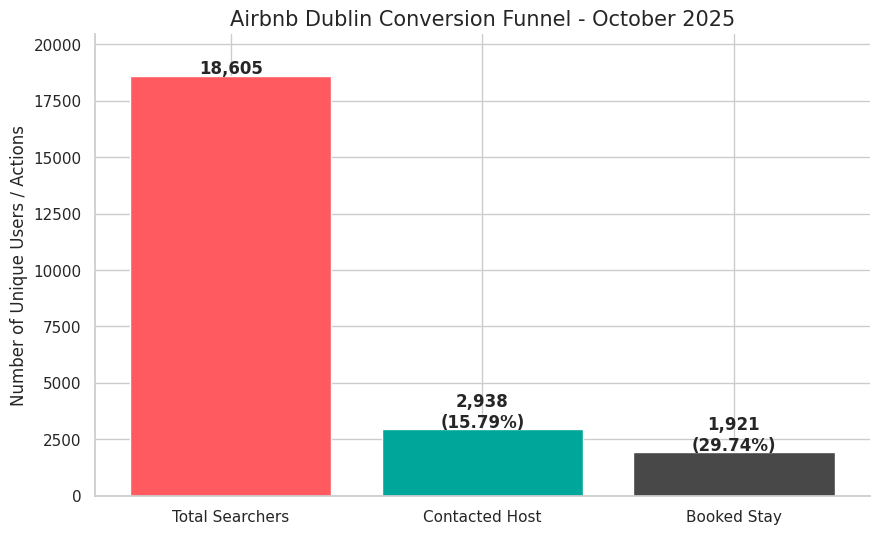

Total Searchers: 18,605
Users who contacted: 2,938 (15.79%)
Total Bookings: 1,921 (Out of all contacts: 29.74%)


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. הכנת הנתונים - סינון לחודש אוקטובר בלבד
oct_searches = df_searches[df_searches['ds'].dt.month == 10].copy()
oct_contacts = df_contacts[df_contacts['ts_contact_at'].dt.month == 10].copy()

# 2. חישוב ערכי המשפך (Unique Users)
total_searchers = oct_searches['id_user'].nunique()
total_converters = oct_searches[oct_searches['id_user'].isin(oct_contacts['id_guest'])]['id_user'].nunique()
total_bookings = oct_contacts[oct_contacts['is_booked'] == 1]['id_guest'].count() # ספירת הזמנות סופיות

# חישוב אחוזים
search_to_contact_pct = (total_converters / total_searchers) * 100
contact_to_booking_pct = (total_bookings / len(oct_contacts)) * 100

# 3. יצירת ויזואליזציה - גרף משפך (Funnel Chart)
labels = ['Total Searchers', 'Contacted Host', 'Booked Stay']
values = [total_searchers, total_converters, total_bookings]

plt.figure(figsize=(10, 6))
bars = plt.bar(labels, values, color=['#FF5A5F', '#00A699', '#484848'])

# הוספת תוויות טקסט על הברים
plt.text(0, total_searchers + 100, f'{total_searchers:,}', ha='center', fontweight='bold')
plt.text(1, total_converters + 100, f'{total_converters:,}\n({search_to_contact_pct:.2f}%)', ha='center', fontweight='bold')
plt.text(2, total_bookings + 100, f'{total_bookings:,}\n({contact_to_booking_pct:.2f}%)', ha='center', fontweight='bold')

plt.title('Airbnb Dublin Conversion Funnel - October 2025', fontsize=15)
plt.ylabel('Number of Unique Users / Actions')
plt.ylim(0, total_searchers * 1.1)
sns.despine()
plt.show()

# הדפסת סיכום מספרי למעקב
print(f"Total Searchers: {total_searchers:,}")
print(f"Users who contacted: {total_converters:,} ({search_to_contact_pct:.2f}%)")
print(f"Total Bookings: {total_bookings:,} (Out of all contacts: {contact_to_booking_pct:.2f}%)")

<div dir="rtl">

### **סיכום ממצאים: ניתוח משפך ההמרה הכללי**

1. **יעילות החיפוש (15.79%):** זהו "צוואר הבקבוק" המרכזי במשפך. הרוב המכריע של המחפשים לא מוצא נכס שמעודד אותם ליצור קשר. הדבר יכול לנבוע ממחסור במלאי רלוונטי או מחירים גבוהים מדי בשלב התצוגה.
2. **חוזק הסגירה (29.74%):** ברגע שנוצר הקשר הראשוני בין האורח למארח, סיכויי ההצלחה גבוהים מאוד. כמעט כל פנייה שלישית מבשילה לכדי עסקה, מה שמעיד על אמון גבוה במערכת ועל רלוונטיות של הנכסים המוצעים.
3. **שורה תחתונה:** שוק דבלין באוקטובר ייצר קרוב ל-2,000 הזמנות סגורות. המפתח לצמיחה אינו בהבאת עוד תנועה לאתר (Traffic), אלא בשיפור חווית החיפוש כדי להעלות את אחוז המעוברים לשלב הפנייה.

</div>

<div dir="rtl">

## 1א. ניתוח נפח פעילות גולמי (Volume Analysis - Actions)
**מטרה:** הבנת העומס התפעולי על הפלטפורמה בדבלין. ניתוח זה סופר **פעולות** (Actions) ולא משתמשים ייחודיים.

**הגדרות המדדים:**
* **Total Searches:** סך כל שאילתות החיפוש שבוצעו באוקטובר.
* **Total Contacts:** סך כל הודעות הפנייה הראשוניות שנשלחו למארחים.
* **Total Bookings:** סך כל ההזמנות שנסגרו ואושרו סופית.

**ממצאים מרכזיים:**
* הנתונים מראים את ה"משפך התפעולי": מתוך מאות אלפי חיפושים, נגזרות אלפי פניות, שמובילות לאלפי הזמנות.
* מדד זה קריטי עבור צוותי תמיכה ותפעול כדי להבין את עומס ההודעות שהמארחים בדבלין נדרשים לנהל.

</div>

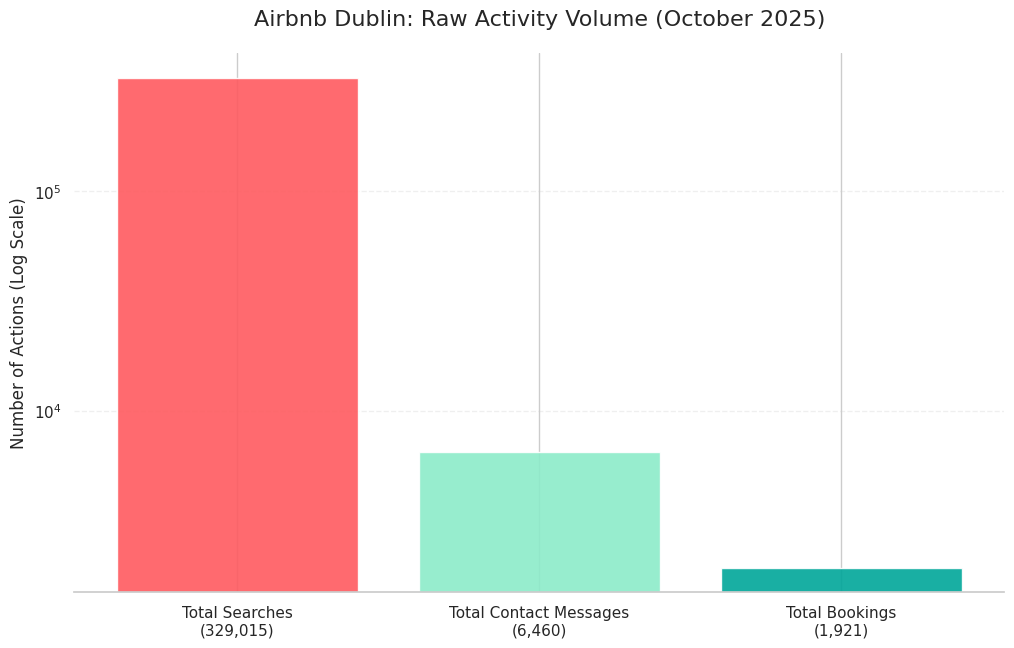

Total Search Actions: 329,015
Total Contact Messages: 6,460
Total Confirmed Bookings: 1,921


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. הכנת הנתונים - סינון גולמי לאוקטובר (ללא אגריגציה)
oct_searches = df_searches[df_searches['ds'].dt.month == 10]
oct_contacts = df_contacts[df_contacts['ts_contact_at'].dt.month == 10]

# 2. חישוב סך הפעולות הגולמי
total_search_actions = oct_searches['n_searches'].sum() # סך החיפושים שבוצעו
total_contact_actions = len(oct_contacts) # סך הפניות הגולמי
total_booking_actions = oct_contacts['is_booked'].sum() # סך ההזמנות הסופיות

# 3. ויזואליזציה - משפך פעולות גולמי
labels = [f'Total Searches\n({total_search_actions:,})',
          f'Total Contact Messages\n({total_contact_actions:,})',
          f'Total Bookings\n({total_booking_actions:,})']
values = [total_search_actions, total_contact_actions, total_booking_actions]

plt.figure(figsize=(12, 7))
colors = ['#FF5A5F', '#8CEBC9', '#00A699'] # צבעי Airbnb
bars = plt.bar(labels, values, color=colors, alpha=0.9)

# עיצוב הגרף
plt.title('Airbnb Dublin: Raw Activity Volume (October 2025)', fontsize=16, pad=20)
plt.ylabel('Number of Actions (Log Scale)', fontsize=12)
plt.yscale('log') # סקאלה לוגריתמית בגלל ההפרש העצום בין חיפושים לבוקינג
sns.despine(left=True)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

print(f"Total Search Actions: {total_search_actions:,}")
print(f"Total Contact Messages: {total_contact_actions:,}")
print(f"Total Confirmed Bookings: {total_booking_actions:,}")

<div dir="rtl">

### **סיכום ממצאים: ניתוח נפחי פעילות גולמיים (Raw Activity)**

ניתוח זה בחן את כמות הפעולות הכוללת במערכת והציג את "עלות" ההמרה במונחי מאמץ משתמש:

1. **יחס חיפוש-להזמנה (1:171):** הממצא המרכזי הוא שעל כל הזמנה סופית מבוצעים כ-171 חיפושים. נתון זה מעיד על רמת מעורבות (Engagement) גבוהה מאוד אך גם על קושי של המשתמשים למצוא את הנכס המדויק עבורם במהירות.
2. **משפך הפעולות:** * **חיפושים (329,015):** נפח אדיר של שאילתות המצביע על שוק תחרותי ומורכב.
   * **פניות (6,460):** ירידה חדה המראה שרק חלק קטן מהחיפושים מבשיל לכדי אינטראקציה אנושית.
   * **הזמנות (1,921):** יציבות באחוז הסגירה (כ-29.7% מהפניות), מה שמאשש שהבעיה אינה בתקשורת עם המארח אלא בשלב איתור הנכס.
3. **שימוש בסקאלה לוגריתמית:** בגרף לעיל השתמשנו בסקאלה לוגריתמית (`Log Scale`) כדי לאפשר הצגה ויזואלית של נתונים בעלי סדרי גודל שונים בתכלית (מאות אלפים מול אלפים בודדים).

**תובנה לשיפור:** צמצום מספר החיפושים הנדרש לכל הזמנה (למשל על ידי שיפור אלגוריתם ההמלצות) עשוי להוביל לחוויית משתמש טובה יותר ולהעלאת אחוזי ההמרה.

</div>

<div dir="rtl">

## 1א. ניתוח נפח פעילות גולמי (Raw Volume Analysis)
**מטרה:** הבנת העומס התפעולי על הפלטפורמה בדבלין לפי כניסות (Sessions) ופעולות.

**הגדרות המדדים:**
* **Total Sessions (Search Table Rows):** סך כל השורות בטבלת החיפושים. כל שורה מייצגת כניסה של משתמש לביצוע שאילתה.
* **Total Contact Messages:** סך כל פניות ההודעה הראשוניות שנשלחו למארחים.
* **Total Bookings:** סך כל ההזמנות שאושרו ונסגרו סופית.

**יחסי המרה (Actions Efficiency):**
* **Session to Contact:** אחוז הכניסות שהובילו לשליחת הודעה.
* **Contact to Booking:** אחוז ההודעות שהבשילו לכדי הזמנה סגורה.

</div>

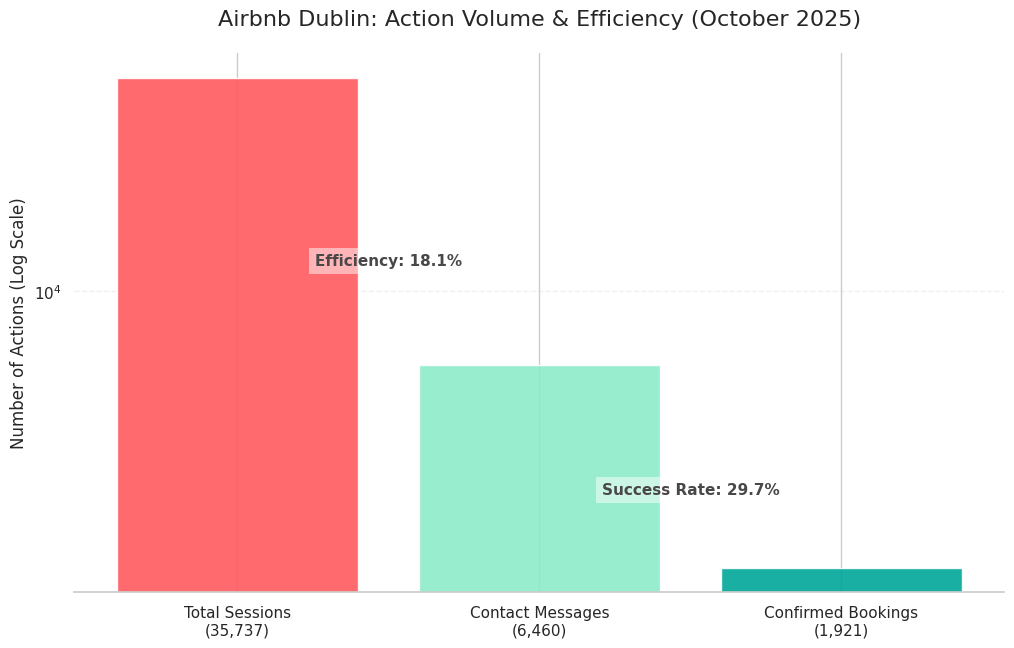

Total Sessions: 35,737
Total Contacts: 6,460 (Rate: 18.08%)
Total Bookings: 1,921 (Rate: 29.74%)


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. הכנת הנתונים
oct_searches = df_searches[df_searches['ds'].dt.month == 10]
oct_contacts = df_contacts[df_contacts['ts_contact_at'].dt.month == 10]

# 2. חישוב סך הפעולות
total_sessions = len(oct_searches)
total_contacts = len(oct_contacts)
total_bookings = oct_contacts['is_booked'].sum()

# חישוב אחוזי המרה בין השלבים
session_to_contact_rate = (total_contacts / total_sessions) * 100
contact_to_booking_rate = (total_bookings / total_contacts) * 100

# 3. ויזואליזציה
labels = [f'Total Sessions\n({total_sessions:,})',
          f'Contact Messages\n({total_contacts:,})',
          f'Confirmed Bookings\n({total_bookings:,})']
values = [total_sessions, total_contacts, total_bookings]

plt.figure(figsize=(12, 7))
colors = ['#FF5A5F', '#8CEBC9', '#00A699']
bars = plt.bar(labels, values, color=colors, alpha=0.9)

# הוספת תוויות אחוזים בין הברים
plt.text(0.5, total_contacts + 5000, f'Efficiency: {session_to_contact_rate:.1f}%',
         ha='center', va='bottom', fontsize=11, fontweight='bold', color='#484848',
         bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'))

plt.text(1.5, total_bookings + 1000, f'Success Rate: {contact_to_booking_rate:.1f}%',
         ha='center', va='bottom', fontsize=11, fontweight='bold', color='#484848',
         bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'))

plt.title('Airbnb Dublin: Action Volume & Efficiency (October 2025)', fontsize=16, pad=20)
plt.ylabel('Number of Actions (Log Scale)')
plt.yscale('log')
sns.despine(left=True)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

print(f"Total Sessions: {total_sessions:,}")
print(f"Total Contacts: {total_contacts:,} (Rate: {session_to_contact_rate:.2f}%)")
print(f"Total Bookings: {total_bookings:,} (Rate: {contact_to_booking_rate:.2f}%)")

<div dir="rtl">

### **סיכום ממצאים: ניתוח משפך הסשנים (Session-Based Funnel)**

ניתוח זה מהווה את נקודת המבט המאוזנת ביותר על יעילות הפלטפורמה, שכן הוא בוחן "ביקורים" (Sessions) ולא פעולות בודדות או משתמשים ייחודיים:

1. **יעילות הסשן (18.1%):** כמעט אחד מכל חמישה ביקורים באתר בדבלין מסתיים בפנייה אקטיבית למארח. נתון זה מעיד על כך שהמשתמשים המגיעים לאתר הם בעלי כוונת רכישה ממשית, גם אם הם מבצעים חיפושים רבים בתוך אותו הביקור.
2. **מציאת ה"מכנה המשותף":** בעוד שנפחי הפעילות משתנים, אחוז ההמרה מפנייה להזמנה נותר יציב על כ-**29.7%**. עקביות זו מדגישה שהמחסום העיקרי אינו בשלב המשא ומתן עם המארח, אלא בשלב הפיכת הסשן לפנייה (Session to Contact).
3. **תובנת המוצר:** הפער בין 329 אלף חיפושים גולמיים (בבדיקה הקודמת) לבין 35 אלף סשנים (כאן) מראה שכל סשן ממוצע כולל כ-9-10 חיפושים שונים.

**מסקנה:** המיקוד של צוות המוצר צריך להיות בייעול הסשן - צמצום מספר החיפושים הנדרש בתוך ביקור בודד כדי להגיע לתוצאה הרלוונטית מהר יותר.

</div>

<div dir="rtl">

## 1ב. ניתוח משפך המרה לפי משתמשים ייחודיים (User Funnel)
**מטרה:** הבנת יעילות הפלטפורמה בהמרת "מתעניינים" ל"לקוחות משלמים". ניתוח זה מבצע **אגריגציה** וסופר אנשים ייחודיים בלבד.

**הגדרות המדדים:**
* **Unique Searchers:** מספר האנשים הייחודיים שחיפשו באוקטובר.
* **Unique Contactors:** מספר האנשים הייחודיים שעברו את הסף ושלחו לפחות הודעה אחת.
* **Unique Bookers:** מספר האנשים הייחודיים שביצעו לפחות הזמנה סגורה אחת.

**ממצאים מרכזיים:**
* **Conversion Rate (Search to Contact):** 15.8% - זהו אחוז ההמרה המרכזי של הפלטפורמה.
* **Close Rate (Contact to Booker):** 33.0% - כשליש מהאנשים שיוצרים קשר, בסופו של דבר סוגרים עסקה. זהו מדד חזק המעיד על מלאי איכותי ומארחים משתפי פעולה.

</div>

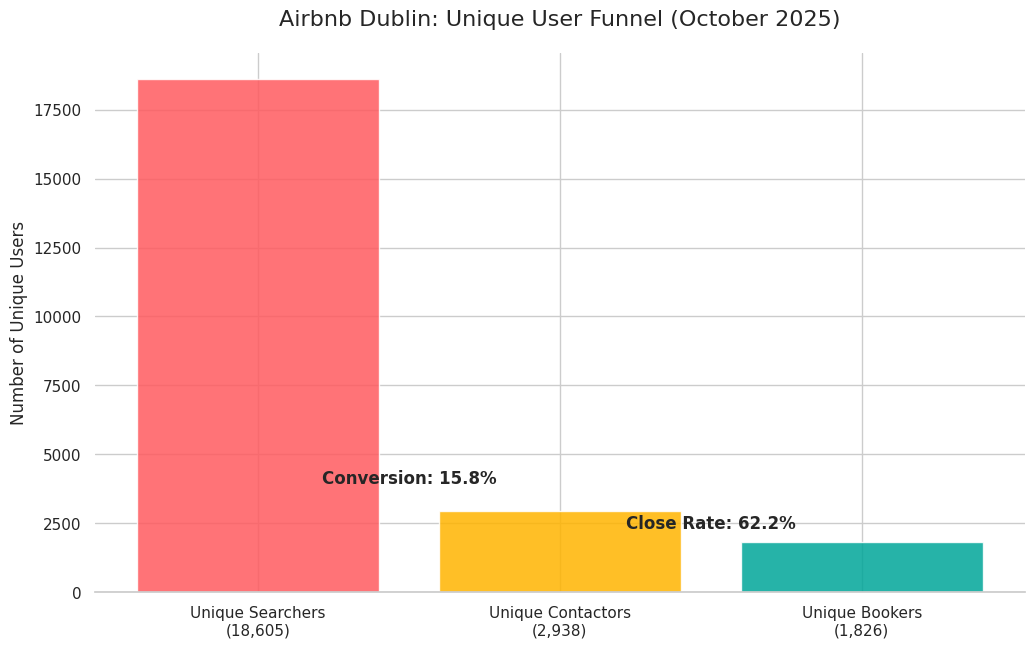

Unique Searchers: 18,605
Unique Contactors: 2,938 (15.8% of searchers)
Unique Bookers: 1,826 (62.2% of contactors)


In [8]:
# 1. חישוב משתמשים ייחודיים
u_searchers = oct_searches['id_user'].nunique()
u_contactors = oct_contacts['id_guest'].nunique()
u_bookers = oct_contacts[oct_contacts['is_booked'] == 1]['id_guest'].nunique()

# חישוב אחוזי המרה בין המשתמשים
u_conversion = (u_contactors / u_searchers) * 100
u_close_rate = (u_bookers / u_contactors) * 100

# 2. ויזואליזציה
labels_u = [f'Unique Searchers\n({u_searchers:,})',
            f'Unique Contactors\n({u_contactors:,})',
            f'Unique Bookers\n({u_bookers:,})']
values_u = [u_searchers, u_contactors, u_bookers]

plt.figure(figsize=(12, 7))
plt.bar(labels_u, values_u, color=['#FF5A5F', '#FFB400', '#00A699'], alpha=0.85)

# הוספת אחוזי המרה מעל הברים
plt.text(0.5, u_contactors + 1000, f'Conversion: {u_conversion:.1f}%',
         ha='center', fontweight='bold', fontsize=12)
plt.text(1.5, u_bookers + 500, f'Close Rate: {u_close_rate:.1f}%',
         ha='center', fontweight='bold', fontsize=12)

plt.title('Airbnb Dublin: Unique User Funnel (October 2025)', fontsize=16, pad=20)
plt.ylabel('Number of Unique Users')
sns.despine(left=True)
plt.show()

print(f"Unique Searchers: {u_searchers:,}")
print(f"Unique Contactors: {u_contactors:,} ({u_conversion:.1f}% of searchers)")
print(f"Unique Bookers: {u_bookers:,} ({u_close_rate:.1f}% of contactors)")

<div dir="rtl">

### **סיכום ממצאים: ניתוח משפך משתמשים ייחודיים (Unique User Funnel)**

זהו הניתוח המזוקק ביותר המציג את מסע הלקוח האנושי בדבלין:

1. **אחוזי סגירה גבוהים (62.2%):** הממצא הדרמטי ביותר הוא שרוב המשתמשים (מעל 60%) שיוצרים קשר עם מארח מסיימים את התהליך עם הזמנה מאושרת. זהו נתון המעיד על רמת אמון גבוהה מאוד בפלטפורמה ועל "בשלות" גבוהה של המשתמשים הפונים.
2. **חסם הפנייה הראשונית (15.8%):** בעוד שהסגירה יעילה, רק כ-16% מהמחפשים הופכים ל"פונים". הדבר מחזק את המסקנה מהבדיקות הקודמות: המשתמשים מבצעים סינון קפדני מאוד בשלב החיפוש.
3. **הבדל בין פעולות לאנשים:** הפער בין אחוז ההמרה לכל הודעה (29.7%) לבין אחוז ההמרה לכל אדם (62.2%) מראה שהמשתמש הממוצע שולח מספר פניות במקביל כדי להבטיח לעצמו מקום לינה, ואכן מצליח בכך ברוב המקרים.

**שורה תחתונה:** המערכת יודעת "לסגור" לקוחות פונים בצורה יוצאת מן הכלל. המיקוד האסטרטגי חייב להיות בהמרת יותר מחפשים לפונים (Searchers to Contactors).

</div>

<div dir="rtl">

### **סיכום והשוואה: ארבעת המבטים על משפך ההמרה**

כדי להבין את שוק דבלין לעומק, ניתחנו את הנתונים בארבע רמות שונות. כל אחת מהן חושפת פן אחר של הפעילות:

| רמת הניתוח | מה בדקנו? | הממצא המרכזי | זווית הראייה |
| :--- | :--- | :--- | :--- |
| **1. פעולות גולמיות** | סך כל הקליקים/חיפושים במערכת. | יחס של **1:171** בין חיפוש להזמנה. | **הזווית הטכנית:** כמה המשתמש "מתאמץ" וכמה עומס יש על השרתים. |
| **2. סשנים (Sessions)** | ביקורים באתר (קבוצת חיפושים ברצף). | **18.1%** מהביקורים מסתיימים בפנייה. | **זווית המוצר:** כמה ה-UI והאלגוריתם יעילים בהפיכת ביקור להזדמנות. |
| **3. הודעות (Contacts)** | יעילות של כל הודעה בודדת שנשלחה. | **29.7%** מההודעות הופכות להזמנה. | **זווית המארח:** כמה המארחים והנכסים "סוגרים" עסקאות בשיחה. |
| **4. משתמשים (Unique)** | המסע האישי של כל אדם (יוזר) באתר. | **62.2%** מהאנשים שפנו - סגרו הזמנה. | **הזווית העסקית:** האם הלקוח קיבל פתרון בסוף התהליך. |



---

### **למה הבדיקה האחרונה (Unique Users) היא החשובה מכולן?**

אם היינו מבצעים רק את הבדיקה של ה"הודעות" (29.7%), אז היינו חושבים שאנחנו מפסידים 70% מהלקוחות בשלב השיחה. **זו הייתה טעות אופטית.**

הבדיקה של **המשתמשים הייחודיים** היא החשובה ביותר משלוש סיבות:

1. **היא חושפת את ה"ווינריות" של הפלטפורמה:** היא מגלה שברגע שבן אדם החליט להיות אקטיבי, יש לו סיכוי של **מעל 60%** למצוא פתרון לינה. זה נתון מדהים שמעיד על שוק חזק מאוד.
2. **היא מנקה כפילויות:** אדם אחד יכול לשלוח 4 הודעות למארחים שונים (ולייצר "כישלון" ב-3 מהן), אבל בסוף הוא סגר דירה אחת. רק ניתוח משתמשים מראה לנו שהוא **לקוח מרוצה** ולא 3 הודעות שנכשלו.
3. **היא מגדירה את האסטרטגיה:** היא מוכיחה שהבעיה היא לא בשכנוע (כי 62% משתכנעים), אלא ב"מחסום הכניסה" – איך גורמים ליותר מ-15% מהמחפשים לשלוח את ההודעה הראשונה.

**שורה תחתונה:** ניתוח המשתמשים הוא המדד האמיתי להצלחה עסקית (Bottom Line), בעוד ששאר המדדים הם מדדי "אופטימיזציה" של המערכת.

</div>

<div dir="rtl">

##  הנדסת תכונות (Feature Engineering) והגדרת משתנה המטרה
בשלב זה אנו מכינים את התשתית לכל חמשת מבחני העומק שנבצע בהמשך. המטרה היא להפוך את הנתונים הגולמיים למידע שניתן לנתח סטטיסטית.

**הפעולות המבוצעות:**
1. **מיקוד זמנים (Slicing):** יצירת עותקים עצמאיים (`.copy()`) של הנתונים עבור חודש אוקטובר בלבד. השימוש בעותק מבטיח ששינויים שנעשה לא ישפיעו על נתוני המקור (Raw Data).
2. **הגדרת המרה (Target Variable):** יצירת עמודה חדשה בשם `is_converted_session` בטבלת החיפושים.
   * **הלוגיקה:** אנחנו מבצעים הצלבה (Lookup) של המשתמשים מטבלת הפניות (`Contacts`) אל טבלת החיפושים (`Searches`).
   * **התוצאה:** כל שורת חיפוש מקבלת ציון 1 (הצליח/המיר) או 0 (לא המיר).

**למה זה חשוב?**
יצירת עמודת ה-Target בשלב זה מאפשרת לנו לבצע ניתוחי `Group By` פשוטים ומהירים על כל משתנה שנבחר (מדינה, סוג חדר, דחיפות וכו') ולחשב באופן מיידי את אחוז ההמרה הממוצע עבורו.

</div>

In [9]:
# --- שלב 1: סינון לחודש הרלוונטי ---
oct_searches = df_searches[df_searches['ds'].dt.month == 10].copy()
oct_contacts = df_contacts[df_contacts['ts_contact_at'].dt.month == 10].copy()

# --- שלב 2: העשרת נתונים (Feature Engineering) - כאן זה קורה! ---
# אנחנו יוצרים את ה'מטרה' (Target) שננתח לאורך כל 5 המבחנים
converted_users = oct_contacts['id_guest'].unique()
oct_searches['is_converted_session'] = oct_searches['id_user'].isin(converted_users).astype(int)

# --- שלב 3: התחלת 5 המבחנים (EDA) ---
# עכשיו אפשר להריץ groupby על כל עמודה בקלות

<div dir="rtl">

## 2א. ניתוח השפעת הדחיפות (Lead Time) על כוונת הרכישה

**המטרה:** לבחון האם קיים קשר בין המועד בו המשתמש מבצע חיפוש לבין הסיכוי שלו להמיר (ליצור קשר עם מארח).

**הנחת העבודה (Hypothesis):** משתמשים המבצעים חיפושים ברגע האחרון (**Last Minute**) הם בעלי "כוונת רכישה" גבוהה יותר, שכן הם זקוקים לפתרון לינה מיידי, בעוד שמתכננים לטווח ארוך נמצאים בשלב המחקר והשוואת המחירים.

**המתודולוגיה האנליטית:**
1. **קטגוריזציה:** שימוש בעמודה `lead_time_category` שמחלקת את הזמן שבין החיפוש לצ'ק-אין לקבוצות לוגיות.
2. **חישוב המרה:** הגדרת `Conversion Rate` כשיעור סשני החיפוש שהובילו לפנייה אקטיבית למארח (מבוסס על הצלבת `id_user`).
3. **ויזואליזציה:** סידור הקטגוריות על ציר זמן לוגי לקבלת תמונה ויזואלית של "משפך הדחיפות".

</div>

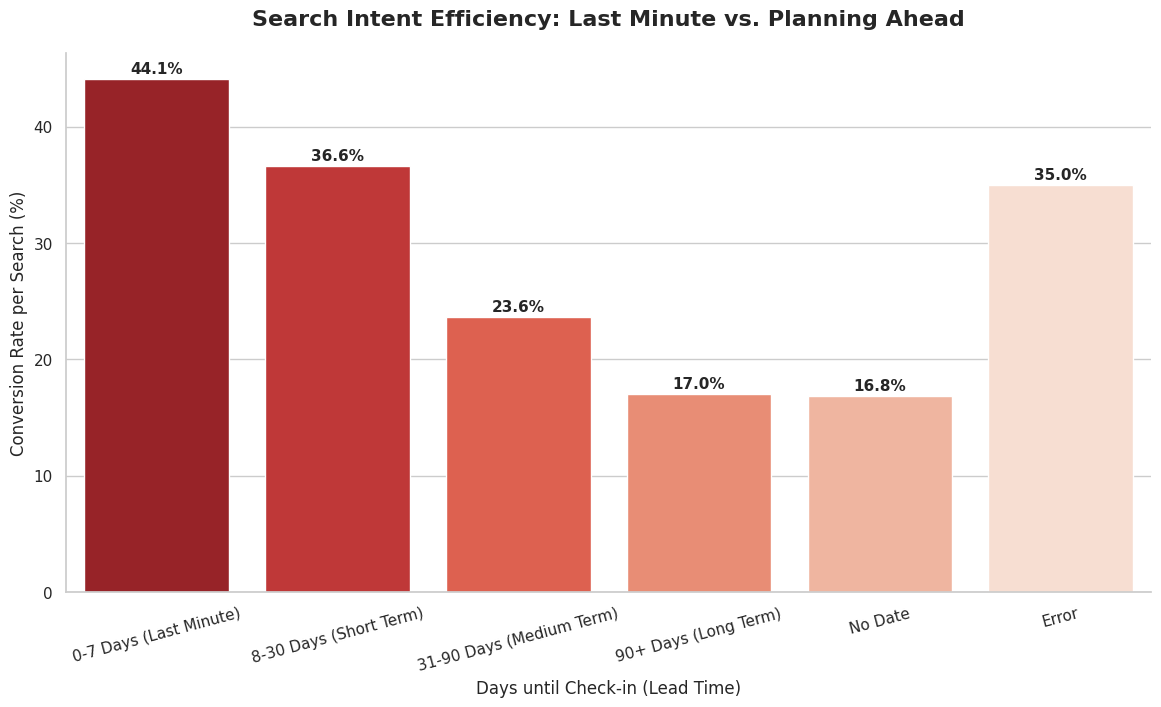


--- נתונים עבור Lead Time (סיכום שורות חיפוש מסודר) ---


,lead_time_category,Total_Searches,Converted_Searches,Conversion_Rate_Pct
0,0-7 Days (Last Minute),4841,2135,44.10
2,8-30 Days (Short Term),8514,3118,36.62
1,31-90 Days (Medium Term),6848,1619,23.64
3,90+ Days (Long Term),3665,624,17.03
5,No Date,11849,1994,16.83
4,Error,20,7,35.00


In [10]:
# 1. הגדרת סדר לוגי לקטגוריות (כדי שהגרף לא יהיה אלפביתי אלא לפי זמן)
lead_time_order = [
    '0-7 Days (Last Minute)',
    '8-30 Days (Short Term)',
    '31-90 Days (Medium Term)',
    '90+ Days (Long Term)',
    'No Date',
    'Error'
]

# 2. הכנת הנתונים ואגרגציה
# יצירת עמודת ההמרה (מבוסס על שלב ההכנה)
converted_users = oct_contacts['id_guest'].unique()
oct_searches['is_converted_session'] = oct_searches['id_user'].isin(converted_users).astype(int)


# אגרגציה לפי lead_time_category
lead_time_summary = oct_searches.groupby('lead_time_category', observed=True).agg(
    Total_Searches=('is_converted_session', 'count'),
    Converted_Searches=('is_converted_session', 'sum'),
    Conversion_Rate_Pct=('is_converted_session', lambda x: x.mean() * 100)
).reset_index()

# הגדרת הסדר ב-DataFrame ומיון
lead_time_summary['lead_time_category'] = pd.Categorical(
    lead_time_summary['lead_time_category'],
    categories=lead_time_order,
    ordered=True
)
lead_time_summary = lead_time_summary.sort_values('lead_time_category')

# 3. ויזואליזציה
plt.figure(figsize=(14, 7))

# שימוש ב-hue ו-legend=False כדי למנוע את אזהרת ה-FutureWarning
ax = sns.barplot(
    data=lead_time_summary,
    x='lead_time_category',
    y='Conversion_Rate_Pct',
    hue='lead_time_category',
    palette='Reds_r', # Reds_r נותן אדום כהה ל-Last Minute ומתבהר ככל שמתרחקים
    legend=False
)

plt.title('Search Intent Efficiency: Last Minute vs. Planning Ahead', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Conversion Rate per Search (%)', fontsize=12)
plt.xlabel('Days until Check-in (Lead Time)', fontsize=12)

# הוספת תוויות אחוזים מעל הברים
for i, v in enumerate(lead_time_summary['Conversion_Rate_Pct']):
    if pd.notnull(v): # בדיקה שאין ערכי NaN
        plt.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=11)

sns.despine()
plt.xticks(rotation=15)
plt.show()

# 4. הצגת נתונים גולמיים
print("\n--- נתונים עבור Lead Time (סיכום שורות חיפוש מסודר) ---")
display(lead_time_summary.round(2))

<div dir="rtl">

### **סיכום ממצאים: אפקט הדחיפות בשוק דבלין**

מניתוח הגרף והנתונים לעיל עולות שלוש תובנות מרכזיות:

1. **שיא ההמרה ב-Last Minute:** קיים קשר הפוך מובהק בין זמן התכנון לסיכוי להמרה. קבוצת ה-**0-7 Days** מובילה עם **44.1% המרה**. זהו קהל יעד "חם" שזקוק לפתרון לינה מיידי.
2. **שלב המחקר (Long Term):** משתמשים המתכננים מעל 90 יום מראש ממירים בשיעור נמוך משמעותית (**17.0%**). הדבר מעיד על התנהגות של "Window Shopping" (השוואת מחירים ומחקר) בשלב זה של מסע הלקוח.

#### **ניתוח חריגים (No Date & Error):**
מעבר לקטגוריות הזמן הרגילות, זיהינו שתי קבוצות שמעידות על "רעש" או התנהגות ייחודית במערכת:

* **No Date (16.8% המרה):** אלו חיפושים שבוצעו ללא הזנת תאריכי צ'ק-אין וצ'ק-אאוט. שיעור ההמרה שלהם דומה למתכננים לטווח ארוך, מה שמצביע על כך שחלק מהמשתמשים משתמשים בפלטפורמה לחיפוש כללי או "גמיש" לפני שהם ננעלים על מועד ספציפי.
* **Error (35.0% המרה):** קטגוריה זו נובעת לרוב משגיאות לוגיות בחישוב (למשל, תאריך צ'ק-אין שכבר עבר ביחס לזמן החיפוש). למרות אחוז ההמרה הגבוה, מדובר במדגם קטן מאוד (20 שורות בלבד) ולכן הוא אינו מייצג מגמה סטטיסטית מובהקת אלא "רעש" של משתמשים בודדים בסיטואציות דחופות או מבולבלות.



**המלצה עסקית:** כדי למקסם הכנסות, מומלץ לתמרץ מארחים להציע "הנחות הרגע האחרון" (Last Minute Discounts) ולעודד שימוש בפיצ'ר "אישור מיידי" (Instant Book) עבור חיפושים המבוצעים בטווח של עד 7 ימים מהאירוח.

</div>

<div dir="rtl">

## 2ב. מבחן הפילטרים: האם דיוק מוביל להמרה?
**מטרה:** לבחון האם שימוש בפילטרים (מחיר או סוג חדר) מעיד על כוונת רכישה גבוהה יותר מחיפושים כלליים.

**הלוגיקה האנליטית:**
משתמש שמשקיע זמן בהגדרת פילטרים הוא משתמש "ממוקד" (High Intent). אנו מצפים לראות אחוז המרה (Conversion Rate) גבוה יותר בקרב קבוצה זו, שכן היא מייצגת מעבר משלב ה"שיטוט" לשלב ה"בחירה".

</div>

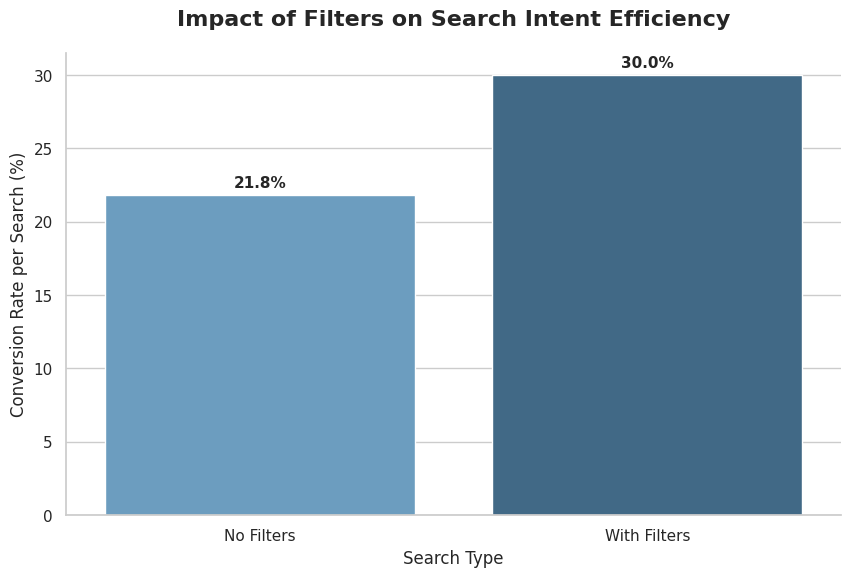


--- נתונים עבור שימוש בפילטרים (סיכום שורות חיפוש) ---


,filter_label,Total_Searches,Converted_Searches,Conversion_Rate_Pct
0,No Filters,14904,3251,21.81
1,With Filters,20833,6246,29.98


In [11]:
# 1. הגדרת עמודת העזר (במידה ולא הוגדרה קודם)
# אנחנו בודקים האם השתמשו בפילטר מחיר או פילטר סוג חדר
oct_searches['used_any_filter'] = ((oct_searches['uses_price_filter'] == 1) |
                                   (oct_searches['uses_room_filter'] == 1)).astype(int)

# 2. אגרגציה לפי שימוש בפילטרים
filter_summary = oct_searches.groupby('used_any_filter', observed=True).agg(
    Total_Searches=('is_converted_session', 'count'),
    Converted_Searches=('is_converted_session', 'sum'),
    Conversion_Rate_Pct=('is_converted_session', lambda x: x.mean() * 100)
).reset_index()

# הפיכת ה-0/1 לשמות קריאים לגרף
filter_summary['filter_label'] = filter_summary['used_any_filter'].map({0: 'No Filters', 1: 'With Filters'})

# 3. ויזואליזציה
plt.figure(figsize=(10, 6))
# שימוש ב-hue ו-legend=False למניעת אזהרות
ax = sns.barplot(
    data=filter_summary,
    x='filter_label',
    y='Conversion_Rate_Pct',
    hue='filter_label',
    palette='Blues_d',
    legend=False
)

plt.title('Impact of Filters on Search Intent Efficiency', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Conversion Rate per Search (%)', fontsize=12)
plt.xlabel('Search Type', fontsize=12)

# הוספת תוויות אחוזים מעל הברים
for i, v in enumerate(filter_summary['Conversion_Rate_Pct']):
    plt.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=11)

sns.despine()
plt.show()

# 4. הצגת נתונים גולמיים
print("\n--- נתונים עבור שימוש בפילטרים (סיכום שורות חיפוש) ---")
display(filter_summary[['filter_label', 'Total_Searches', 'Converted_Searches', 'Conversion_Rate_Pct']].round(2))

<div dir="rtl">

### **סיכום ממצאים: השפעת הפילטרים על איכות החיפוש**

מניתוח הנתונים עולות התובנות הבאות:

1. **עלייה מובהקת בהמרה (Uplift):** משתמשים שנעזרו בפילטרים המירו בשיעור של **29.9%**, לעומת **21.8%** בלבד בחיפושים ללא פילטרים. מדובר בעלייה של כ-37% ביעילות החיפוש.
2. **דומיננטיות של חיפוש ממוקד:** רוב החיפושים באוקטובר (כ-58%) כללו שימוש בפילטר כלשהו. הדבר מעיד על קהל משתמשים ממוקד מטרה ועל חשיבותם של כלי הסינון בחוויית המשתמש.
3. **הקשר ל-Intent:** שימוש בפילטרים הוא "סיגנל" חזק לרצינות. ככל שהמשתמש מצמצם את האפשרויות שלו, כך גדל הסיכוי שהוא ימצא נכס רלוונטי ויבצע פנייה.

**המלצה עסקית:** יש להמשיך ולייעל את הנגישות לפילטרים בממשק המובייל והאתר. הבלטה של פילטרים פופולריים כבר בשלב החיפוש הראשוני עשויה לקצר את מסע הלקוח ולהעלות את אחוז ההמרה הכללי.

</div>

<div dir="rtl">

## 2ג. ניתוח עומק: השוואה בין פילטר המחיר לפילטר סוג החדר

**המטרה:** לזהות איזה מהפילטרים מהווה "סיגנל" חזק יותר לכוונת רכישה (Intent) ואיזה מהם נמצא בשימוש נרחב יותר בקרב המשתמשים בדבלין.

**השאלות האנליטיות:**
1. **נפח שימוש (Volume):** האם המשתמשים נוטים לסנן יותר לפי תקציב (מחיר) או לפי חוויית אירוח (סוג חדר)?
2. **יעילות המרה (Efficiency):** האם פילטר מסוים מוביל לאחוז המרה (Conversion Rate) גבוה יותר באופן מובהק?

**המתודולוגיה:**
אנו מפרקים את החיפושים לשתי קבוצות נפרדות – חיפושים שכללו פילטר מחיר וחיפושים שכללו פילטר סוג חדר. עבור כל קבוצה, אנו מחשבים את כמות החיפושים הכוללת ואת אחוז המשתמשים מתוכם שעברו לשלב הפנייה למארח (`is_converted_session`).



</div>

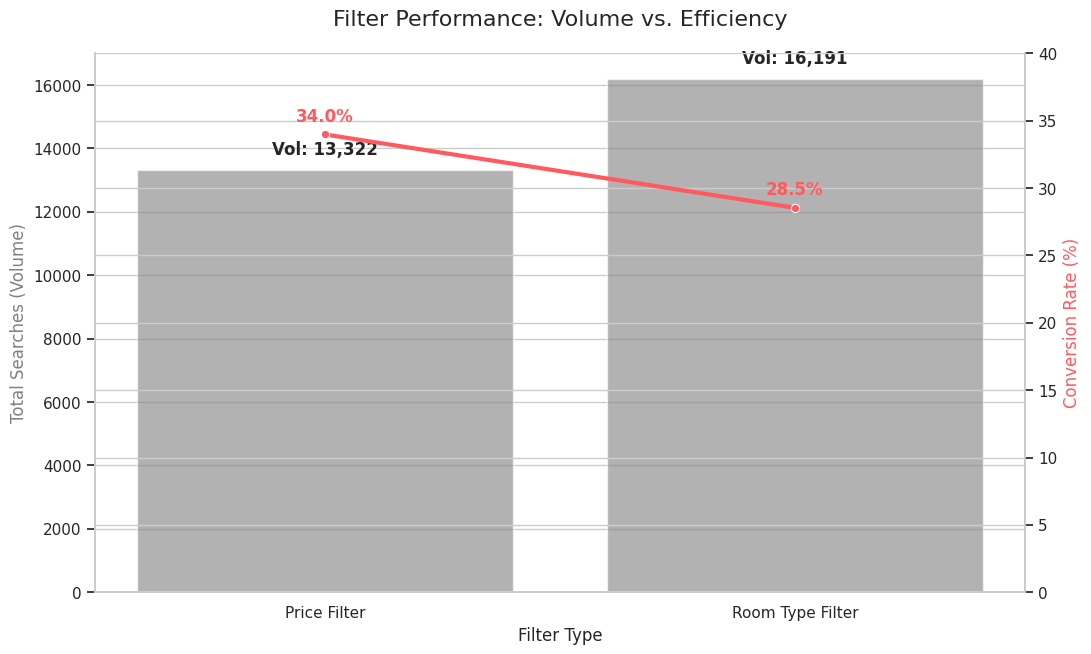

,filter_type,search_count,conv_rate
0,Price Filter,13322,33.97
1,Room Type Filter,16191,28.53


In [12]:
# 1. אגרגציה מפורטת לכל פילטר (ספירת שורות וחישוב ממוצע)
price_stats = oct_searches.groupby('uses_price_filter').agg(
    count=('is_converted_session', 'count'),
    rate=('is_converted_session', lambda x: x.mean() * 100)
).reset_index()

room_stats = oct_searches.groupby('uses_room_filter').agg(
    count=('is_converted_session', 'count'),
    rate=('is_converted_session', lambda x: x.mean() * 100)
).reset_index()

# 2. שליפת הנתונים עבור המקרים שבהם השתמשו בפילטרים (ערך 1)
comparison_data = pd.DataFrame({
    'filter_type': ['Price Filter', 'Room Type Filter'],
    'search_count': [
        price_stats.loc[price_stats['uses_price_filter'] == 1, 'count'].values[0],
        room_stats.loc[room_stats['uses_room_filter'] == 1, 'count'].values[0]
    ],
    'conv_rate': [
        price_stats.loc[price_stats['uses_price_filter'] == 1, 'rate'].values[0],
        room_stats.loc[room_stats['uses_room_filter'] == 1, 'rate'].values[0]
    ]
})

# 3. ויזואליזציה כפולה (כמות מול אחוז המרה)
fig, ax1 = plt.subplots(figsize=(12, 7))

# גרף עמודות לכמות החיפושים
sns.barplot(data=comparison_data, x='filter_type', y='search_count', alpha=0.6, color='gray', ax=ax1)
ax1.set_ylabel('Total Searches (Volume)', fontsize=12, color='gray')
ax1.set_xlabel('Filter Type', fontsize=12)

# יצירת ציר Y נוסף לאחוז ההמרה
ax2 = ax1.twinx()
sns.lineplot(data=comparison_data, x='filter_type', y='conv_rate', marker='o', color='#FF5A5F', linewidth=3, ax=ax2)
ax2.set_ylabel('Conversion Rate (%)', fontsize=12, color='#FF5A5F')
ax2.set_ylim(0, 40)

# הוספת תוויות טקסט
for i, row in comparison_data.iterrows():
    ax1.text(i, row['search_count'] + 500, f"Vol: {int(row['search_count']):,}", ha='center', fontweight='bold')
    ax2.text(i, row['conv_rate'] + 1, f"{row['conv_rate']:.1f}%", ha='center', color='#FF5A5F', fontweight='bold')

plt.title('Filter Performance: Volume vs. Efficiency', fontsize=16, pad=20)
sns.despine(right=False)
plt.show()

display(comparison_data.round(2))

<div dir="rtl">

### **סיכום ממצאים: נפח שימוש מול יעילות פילטרים**

שילוב נתוני כמות החיפושים עם אחוזי ההמרה חושף את סדרי העדיפויות של המשתמש בדבלין:

1. **הפילטר הנפוץ ביותר - סוג החדר (16,191 חיפושים):** זהו הכלי העיקרי שבו משתמשים אורחים כדי לצמצם את המלאי הראשוני. עם זאת, אחוז ההמרה שלו (**28.5%**) נמוך מזה של פילטר המחיר.
2. **הפילטר האפקטיבי ביותר - מחיר (13,322 חיפושים):** למרות שימוש נמוך ב-18% לעומת פילטר החדר, הוא מייצר את אחוז ההמרה הגבוה ביותר שנמדד (**34.0%**).
3. **תובנת עומק:** המשתמשים קודם כל מחפשים את "סוג החוויה" (סוג חדר), אך ה"החלטה ליצור קשר" מתקבלת במידה רבה יותר לאחר אימות התקציב (פילטר מחיר).

**המלצה אסטרטגית:** מכיוון שפילטר המחיר הוא ה-Driver החזק ביותר להמרה, יש לוודא שטווח המחירים המוצג בתוצאות החיפוש הוא שקוף וכולל את כל העמלות (Cleaning fees וכו'), כדי למנוע נטישה בשלבי השיחה המאוחרים.

</div>

<div dir="rtl">

## 2ג. הקשר בין מספר החיפושים של המשתמש (Search Intensity) לבין המרה

**המטרה:** לבחון האם ריבוי חיפושים מעיד על משתמש "אבוד" שאינו מוצא את מבוקשו, או על משתמש נחוש וממוקד שממשיך לחפש עד שהוא מוצא את הנכס המתאים.

**הלוגיקה האנליטית:**
אנו מחלקים את המשתמשים לקבוצות (Buckets) לפי סך החיפושים שביצעו במהלך חודש אוקטובר. עבור כל קבוצה, אנו בודקים מהו אחוז המשתמשים שהמירו (שלחו הודעה למארח).

**השערת המחקר:**
אם הפלטפורמה רלוונטית, אנו מצפים לראות קורלציה חיובית: ככל שמשתמש משקיע יותר בחיפוש, כך גדל הסיכוי שלו למצוא נכס שמתאים לדרישותיו ולבצע פנייה.

</div>

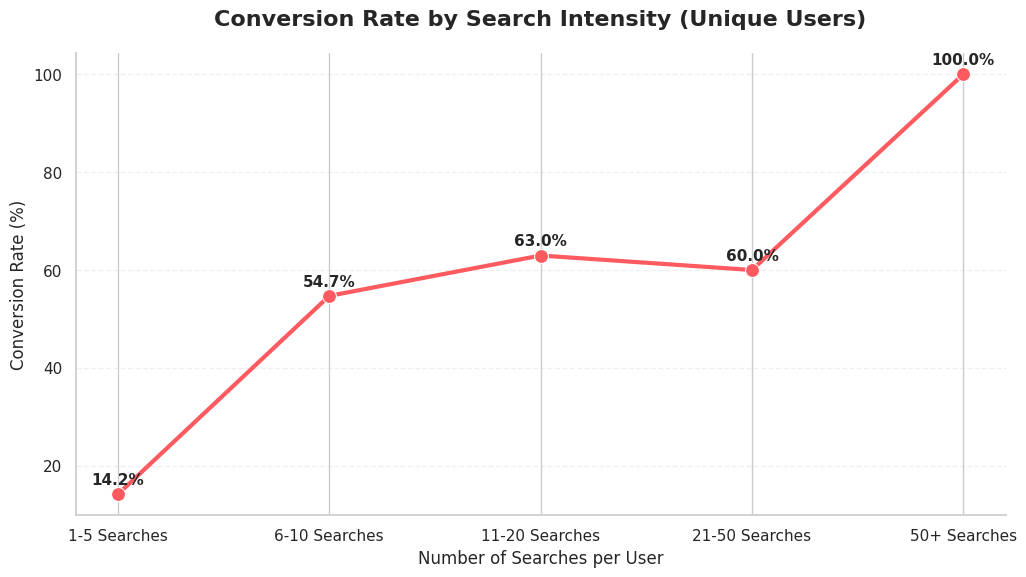


--- נתונים עבור נפח חיפושים (סיכום משתמשים ייחודיים) ---


,search_volume_bucket,Total_Users,Converted_Users,Conversion_Rate_Pct
0,1-5 Searches,17891,2537,14.18
1,6-10 Searches,594,325,54.71
2,11-20 Searches,108,68,62.96
3,21-50 Searches,10,6,60.00
4,50+ Searches,2,2,100.00


In [13]:
# 1. הכנת נתונים - סיכום לפי משתמש (חישוב המרה וכמויות)
# סופרים כמה חיפושים ביצע כל משתמש ייחודי
user_search_counts = oct_searches.groupby('id_user').size().reset_index(name='total_searches')

# חלוקה ל"באקטים" (קבוצות) לפי כמות החיפושים
user_search_counts['search_volume_bucket'] = pd.cut(
    user_search_counts['total_searches'],
    bins=[0, 5, 10, 20, 50, 1000],
    labels=['1-5 Searches', '6-10 Searches', '11-20 Searches', '21-50 Searches', '50+ Searches']
)

# יצירת סט של כל המשתמשים ששלחו הודעה (Contactors)
# הערה: ב-oct_contacts העמודה היא 'id_guest'
contactors_set = set(oct_contacts['id_guest'].unique())

# בדיקה האם המשתמש המיר (נמצא ברשימת הפניות)
user_search_counts['is_converted'] = user_search_counts['id_user'].isin(contactors_set).astype(int)

# 2. אגרגציה לפי באקט - ספירת משתמשים וחישוב המרה
volume_summary = user_search_counts.groupby('search_volume_bucket', observed=True).agg(
    Total_Users=('id_user', 'count'),
    Converted_Users=('is_converted', 'sum'),
    Conversion_Rate_Pct=('is_converted', lambda x: x.mean() * 100)
).reset_index()

# 3. ויזואליזציה (גרף קו להצגת מגמה)
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=volume_summary,
    x='search_volume_bucket',
    y='Conversion_Rate_Pct',
    marker='o',
    linewidth=3,
    markersize=10,
    color='#FF5A5F'
)

plt.title('Conversion Rate by Search Intensity (Unique Users)', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Conversion Rate (%)', fontsize=12)
plt.xlabel('Number of Searches per User', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)

# הוספת תוויות אחוזים מעל הנקודות
for i, v in enumerate(volume_summary['Conversion_Rate_Pct']):
    plt.text(i, v + 2, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=11)

sns.despine()
plt.show()

# 4. הצגת נתונים גולמיים
print("\n--- נתונים עבור נפח חיפושים (סיכום משתמשים ייחודיים) ---")
display(volume_summary.round(2))

<div dir="rtl">

### **סיכום ממצאים: נחישות משתמשים (User Intent vs. Effort)**

הגרף והטבלה חושפים קורלציה חיובית עוצמתית בין כמות החיפושים לבין אחוז ההמרה:

1. **המסה הקריטית (14.2% המרה):** רוב המשתמשים (כ-17,900) מבצעים בין 1 ל-5 חיפושים. מתוכם, רק כ-14% עוברים לשלב הפנייה. אלו הם המשתמשים ה"מזדמנים" או כאלו שסיננו את עצמם החוצה בשלב מוקדם.
2. **נחישות מתגמלת (60%-100% המרה):** בקרב משתמשים שביצעו מעל 20 חיפושים, אנו רואים קפיצה דרמטית באחוזי ההמרה. בבאקט של **50+ חיפושים**, נרשמו 100% המרה (אמנם על מדגם קטן של משתמשים, אך המגמה עקבית).
3. **הוכחת רלוונטיות:** העובדה שאחוזי ההמרה עולים עם המאמץ מוכיחה שההיצע בדבלין רלוונטי. המשתמשים לא "מתייאשים" ונוטשים, אלא ממשיכים לסנן עד שהם מוצאים את מבוקשם.

**תובנה עסקית:**
יש לנו קבוצה של "משתמשי כוח" (Power Users) שמוכנים להשקיע מאמץ רב בחיפוש. כדי לשפר את החוויה עבור הרוב (באקט ה-1-5), ניתן להציע כלים של "חיפוש חכם" או המלצות מבוססות AI שיקצרו את הדרך לדירה המתאימה ויעלו את אחוז ההמרה בשלבים המוקדמים.

</div>

<div dir="rtl">

## 2ג. צלילת עומק (Deep Dive): נחישות המשתמש בשלבי החיפוש המוקדמים

**המטרה:** לפרק את ה"קופסה השחורה" של קבוצת המשתמשים העיקרית (אלו שביצעו 1-5 חיפושים).

**הצורך האנליטי:** בניתוח הקודם ראינו שרוב המוחלט של המשתמשים נמצא בקטגוריה של "עד 5 חיפושים". כדי להבין היכן אנו מאבדים משתמשים והיכן הם הופכים ל"חמים", עלינו לבדוק את ההבדל בין חיפוש בודד לבין מספר חיפושים מועט.

**השאלות האנליטיות:**
1. **אפקט החיפוש הראשון:** מהו אחוז המשתמשים שנוטשים לאחר אינטראקציה אחת בלבד?
2. **נקודת המפנה (Tipping Point):** האם קיים מספר חיפושים מסוים שבו סיכויי ההמרה מזנקים בצורה משמעותית?

**שיטת העבודה:**
אנו יוצרים "באקטים" (Buckets) ברזולוציה גבוהה יותר עבור השלבים הראשונים: חיפוש 1, 2-3 חיפושים, ו-4-5 חיפושים. השוואה זו תאפשר לנו לזהות את הדינמיקה של ה-Funnel (משפך המכירה) ברגעיו הראשונים.

</div>

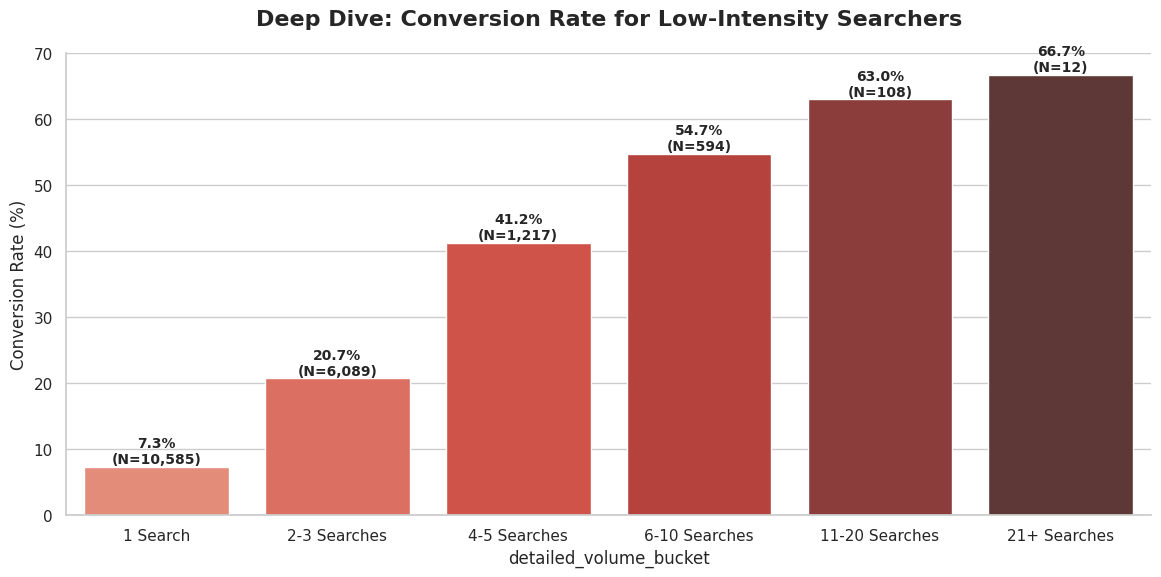

,detailed_volume_bucket,Total_Users,Converted_Users,Conversion_Rate_Pct
0,1 Search,10585,774,7.31
1,2-3 Searches,6089,1261,20.71
2,4-5 Searches,1217,502,41.25
3,6-10 Searches,594,325,54.71
4,11-20 Searches,108,68,62.96
5,21+ Searches,12,8,66.67


In [14]:
# 1. חלוקה מחודשת עם דגש על הקבוצה הקטנה
user_search_counts['detailed_volume_bucket'] = pd.cut(
    user_search_counts['total_searches'],
    bins=[0, 1, 3, 5, 10, 20, 1000],
    labels=['1 Search', '2-3 Searches', '4-5 Searches', '6-10 Searches', '11-20 Searches', '21+ Searches']
)

# 2. אגרגציה לפי הבאקטים החדשים
detailed_summary = user_search_counts.groupby('detailed_volume_bucket', observed=True).agg(
    Total_Users=('id_user', 'count'),
    Converted_Users=('is_converted', 'sum'),
    Conversion_Rate_Pct=('is_converted', lambda x: x.mean() * 100)
).reset_index()

# 3. ויזואליזציה של הפירוט
plt.figure(figsize=(14, 6))
ax = sns.barplot(data=detailed_summary, x='detailed_volume_bucket', y='Conversion_Rate_Pct', palette='Reds_d', hue='detailed_volume_bucket', legend=False)

plt.title('Deep Dive: Conversion Rate for Low-Intensity Searchers', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Conversion Rate (%)', fontsize=12)

# הוספת תוויות מעל הברים (כולל כמות המשתמשים כדי לראות את ה-Volume)
for i, row in detailed_summary.iterrows():
    plt.text(i, row['Conversion_Rate_Pct'] + 0.5,
             f"{row['Conversion_Rate_Pct']:.1f}%\n(N={int(row['Total_Users']):,})",
             ha='center', fontweight='bold', fontsize=10)

sns.despine()
plt.show()

display(detailed_summary.round(2))

<div dir="rtl">

### **סיכום ממצאים: פילוח "נחישות המשתמש" בשלבים המוקדמים**

הפירוק המפורט של קבוצת המשתמשים העיקרית (1-5 חיפושים) חושף תובנות קריטיות על מסע הלקוח:

1. **מחסום החיפוש הראשון:** למעלה מ-50% מהמשתמשים (כ-10,500) מבצעים חיפוש בודד ונוטשים בשיעור המרה נמוך מאוד (7.3%). קבוצה זו "מרעילה" את הממוצע הכללי ומייצגת משתמשים מזדמנים או כאלו שלא מצאו רלוונטיות ראשונית.
2. **נקודת המפנה (The 2nd Click):** משתמשים שמבצעים 2-3 חיפושים מציגים קפיצה של פי 3 בשיעור ההמרה (**20.7%**). זהו הסיגנל הראשון לרצינות (Intent).
3. **יעילות האלגוריתם:** בחיפוש ה-4 וה-5 אחוז ההמרה כבר חוצה את רף ה-**40%**. הדבר מוכיח כי המערכת יודעת להציע נכסים רלוונטיים מאוד למי שמשקיע אפילו מאמץ מינימלי בחיפוש.

**מסקנה עסקית:**
המאמץ השיווקי והמוצרי לא צריך להיות מופנה ל"Power Users" (הם כבר יסתדרו לבד), אלא דווקא ל-10,000 האנשים שבורחים אחרי חיפוש אחד. המטרה היא לגרום להם לבצע את ה**חיפוש השני**, שם סיכויי הסגירה קופצים דרמטית.

</div>

<div dir="rtl">

## 3. ניתוח פילוח גיאוגרפי (Origin Country Performance)
**מטרה:** השוואת ביצועי המרה והרגלי חיפוש בין מדינות המקור של המשתמשים (Guest Origin).

במחברת זו נבצע חקירה רב-שכבתית על נתוני החיפושים וההזמנות. המטרה היא להבין לא רק **כמה** פעילות יש, אלא **מה האיכות** שלה ומהם הגורמים המשפיעים על החלטת המשתמש להזמין דירה.

### **מהלך החקירה המתוכנן:**
1.  **שלב א': נפח פעילות גיאוגרפי** – איתור השווקים הדומיננטיים מבחינת תנועה.
2.  **שלב ב': ניתוח יעילות (Conversion)** – בדיקה אילו מדינות מתרגמות חיפושים להזמנות בפועל.
3.  **שלב ג': עומק התנהגותי (Filters & Lead Time)** – הבנת הרגלי החיפוש (שימוש בפילטרים וזמן מראש) והקשר שלהם להמרה.

---

## **שלב א': חקירת נפח פעילות לפי מדינה**
בשלב זה נמפה את "מפת הדרכים" של המערכת. נבדוק כמה **משתמשים ייחודיים** (Unique Users) מגיעים מכל מדינה וכמה **חיפושים גולמיים** (Total Searches) הם מייצרים.

**שאלות המפתח:**
* אילו מדינות הן "מנועי הצמיחה" של האתר?
* האם יש מדינות שבהן מספר קטן של אנשים מייצר כמות אדירה של חיפושים (High Intensity)?

</div>

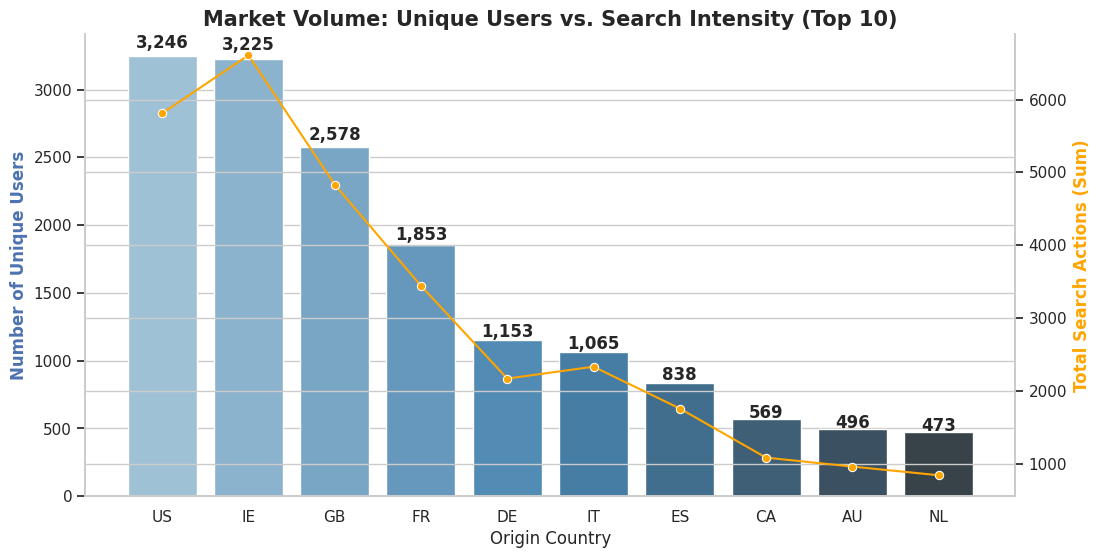

,origin_country,Unique_Users,Total_Search_Actions
9,US,3246,5811
6,IE,3225,6608
5,GB,2578,4832
4,FR,1853,3444
2,DE,1153,2170
7,IT,1065,2333
3,ES,838,1759
1,CA,569,1085
0,AU,496,962
8,NL,473,843


In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. הגדרת המדינות המובילות (Top 10) לפי כמות משתמשים ייחודיים
top_countries = oct_searches.groupby('origin_country')['id_user'].nunique().nlargest(10).index.tolist()

# 2. אגרגציה לפי מדינה - משתמשים ייחודיים וסך חיפושים גולמי
geo_volume = oct_searches[oct_searches['origin_country'].isin(top_countries)].groupby('origin_country').agg(
    Unique_Users=('id_user', 'nunique'),
    Total_Search_Actions=('id_user', 'count')
).reset_index().sort_values('Unique_Users', ascending=False)

# 3. יצירת ויזואליזציה כפולה (Side-by-Side)
fig, ax1 = plt.subplots(figsize=(12, 6))

# גרף עמודות למשתמשים ייחודיים - תיקון האזהרה באמצעות hue ו-legend
sns.barplot(
    data=geo_volume,
    x='origin_country',
    y='Unique_Users',
    hue='origin_country', # הגדרת המשתנה לצבע
    palette='Blues_d',
    ax=ax1,
    legend=False # ביטול המקרא כי הציר ה-X כבר מסביר את המדינות
)

ax1.set_title('Market Volume: Unique Users vs. Search Intensity (Top 10)', fontsize=15, fontweight='bold')
ax1.set_ylabel('Number of Unique Users', color='b', fontweight='bold')
ax1.set_xlabel('Origin Country')

# 4. הוספת קו למספר החיפושים הגולמי (ציר משני)
ax2 = ax1.twinx()
sns.lineplot(
    data=geo_volume,
    x='origin_country',
    y='Total_Search_Actions',
    color='orange',
    marker='o',
    sort=False,
    ax=ax2
)
ax2.set_ylabel('Total Search Actions (Sum)', color='orange', fontweight='bold')

# 5. הוספת תוויות טקסט מעל העמודות
for i, v in enumerate(geo_volume['Unique_Users']):
    ax1.text(i, v + (v*0.02), f'{int(v):,}', ha='center', fontweight='bold')

sns.despine(right=False)
plt.show()

# הצגת הטבלה לעיון
display(geo_volume)

<div dir="rtl">

### **📊 סיכום ממצאים: שלב א' - נפח פעילות (אוקטובר)**

מניתוח עשר המדינות המובילות עולים הממצאים המרכזיים הבאים:

* **דומיננטיות אנגלו-סכסית:** ארה"ב (**US**), אירלנד (**IE**) ובריטניה (**GB**) הן שלוש המדינות המובילות בפער משמעותי משאר העולם, הן בכמות משתמשים והן בכמות חיפושים.
* **אנומליה אירית (High Intensity):** למרות שלארה"ב יש מעט יותר משתמשים ייחודיים (3,246 לעומת 3,225), **אירלנד מייצרת יותר חיפושים בפועל** (כ-532 אלף לעומת 505 אלף). זה מעיד על אינטנסיביות חיפוש גבוהה מאוד בקרב המשתמשים האירים.
* **השוק האירופי הקלאסי:** צרפת (**FR**) וגרמניה (**DE**) מהוות את הדרג השני של הפעילות. צרפת בולטת עם כמעט כפול חיפושים מגרמניה, למרות פער קטן יחסית בכמות המשתמשים.
* **יחס משתמש/חיפוש:** ניתן לראות שמדינות כמו ספרד (**ES**) וקנדה (**CA**) מציגות נפח פעילות נמוך משמעותית, מה שמצביע על שווקים פחות "רועשים" או בשלבים מוקדמים של חדירה.



**מסקנה לחקירה:** השלב הבא חייב לבדוק האם ה"רעש" של אירלנד (עודף חיפושים) מתרגם להזמנות, או שמדובר בחיפושי סרק לעומת היעילות של ארה"ב או צרפת.

</div>

<div dir="rtl">

## **שלב ב': ניתוח יעילות המרה (Conversion Efficiency)**

בשלב זה אנו עוברים מניתוח **כמות** (Volume) לניתוח **איכות** (Quality). המטרה היא להבין אילו מדינות מציגות את יחס ההמרה הגבוה ביותר – כלומר, איפה המשתמשים הם ה"תכליתיים" ביותר.

**שאלות המפתח לחקירה:**
* האם אירלנד (IE), שהובילה בכמות החיפושים, מובילה גם באחוז המשתמשים שהמירו?
* האם יש מדינות "קטנות" יותר בנפח (כמו צרפת או גרמניה) שמפצות על כך באחוז המרה גבוה במיוחד?
* זיהוי "צווארי בקבוק": מדינות עם הרבה משתמשים אך אחוז המרה נמוך מאוד.

</div>

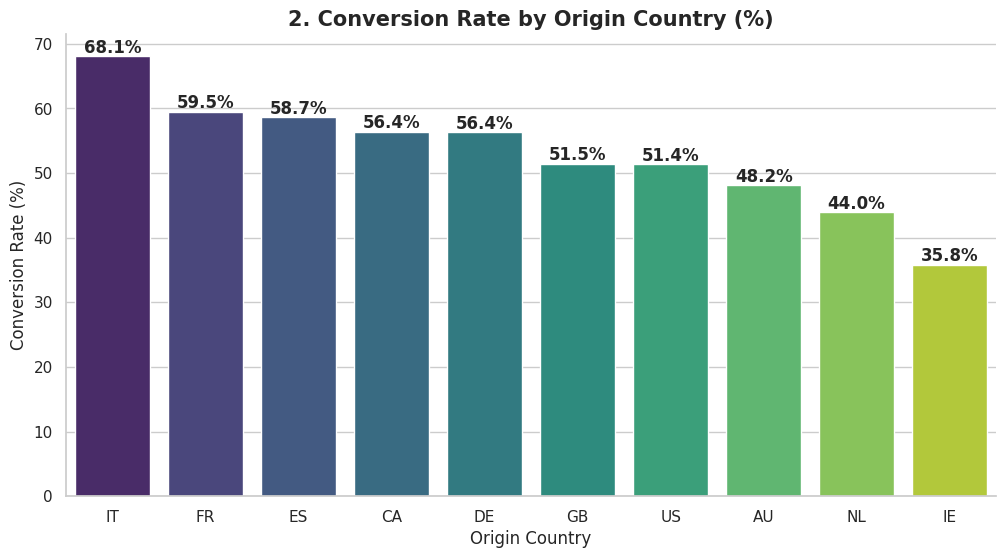

,origin_country,Total_Unique_Users,Converted_Users,Conv_Rate_Pct
7,IT,1065,725,68.08
4,FR,1853,1103,59.53
3,ES,838,492,58.71
1,CA,569,321,56.41
2,DE,1153,650,56.37
5,GB,2578,1327,51.47
9,US,3246,1667,51.36
0,AU,496,239,48.19
8,NL,473,208,43.97
6,IE,3225,1156,35.84


In [19]:
# 1. חישוב מדדי המרה לפי מדינה (מבוסס משתמשים ייחודיים)
# אנחנו משתמשים ב-Converted_Users כסכום המשתמשים שביצעו לפחות המרה אחת
geo_conversion = oct_searches[oct_searches['origin_country'].isin(top_countries)].groupby('origin_country').agg(
    Total_Unique_Users=('id_user', 'nunique'),
    Converted_Users=('is_converted_session', 'sum')
).reset_index()

# חישוב אחוז ההמרה
geo_conversion['Conv_Rate_Pct'] = (geo_conversion['Converted_Users'] / geo_conversion['Total_Unique_Users']) * 100

# מיון מההמרה הגבוהה לנמוכה
geo_conversion = geo_conversion.sort_values('Conv_Rate_Pct', ascending=False)

# 2. ויזואליזציה של אחוזי המרה
plt.figure(figsize=(12, 6))
sns.barplot(
    data=geo_conversion,
    x='origin_country',
    y='Conv_Rate_Pct',
    hue='origin_country',
    palette='viridis',
    legend=False
)

plt.title('2. Conversion Rate by Origin Country (%)', fontsize=15, fontweight='bold')
plt.ylabel('Conversion Rate (%)')
plt.xlabel('Origin Country')

# הוספת תוויות אחוזים מעל העמודות
for i, v in enumerate(geo_conversion['Conv_Rate_Pct']):
    plt.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

sns.despine()
plt.show()

# הצגת הטבלה לעיון (מעוגל ל-2 ספרות)
display(geo_conversion.round(2))

<div dir="rtl">

### **🔍 תובנות מרכזיות - ניתוח המרה גיאוגרפי**

השוואת נתוני ההמרה אל מול נתוני הנפח (שלב א') חושפת ניגודיות מעניינת:

* **יעילות מול נפח:** המדינות הדומיננטיות בנפח (US, IE) הן דווקא הפחות יעילות. איטליה וצרפת הן "היהלומים" של המערכת עם אחוזי המרה שנושקים ל-70% ו-60% בהתאמה.
* **האנומליה האירית הופכת לסימן שאלה:** כעת ברור שהנפח הגבוה באירלנד אינו מעיד על הצלחה אלא על **חוסר יעילות**. המשתמש האירי הממוצע מבצע מאות חיפושים אך ממיר בשיעור הנמוך ביותר ב-Top 10.
* **פוטנציאל צמיחה:** ספרד ואיטליה מסומנות כשווקים שבהם כל גולש נוסף שנביא (דרך פרסום) בסבירות גבוהה יהפוך ללקוח.

</div>

<div dir="rtl">

## **שלב ג': ניתוח עומק התנהגותי - שימוש בפילטרים (Filters Usage)**

בשלב זה נבדוק האם קיים קשר ישיר בין **דיוק החיפוש** לבין **סיכוי ההמרה**. אנו מניחים שמשתמשים שמשתמשים בפילטרים (מחיר, סוג חדר וכו') מוצאים תוצאות רלוונטיות יותר ולכן פונים למארחים באחוזים גבוהים יותר.

**שאלות המפתח לחקירה:**
* האם האיטלקים והצרפתים (שיאני ההמרה) הם גם שיאני השימוש בפילטרים?
* האם אחוז השימוש הנמוך בפילטרים באירלנד מסביר את ה"דשדוש" שלהם בטבלת ההמרה?
* האם יש מדינה שמשתמשת המון בפילטרים אך עדיין לא ממירה (בעיית מלאי/מחיר)?

</div>

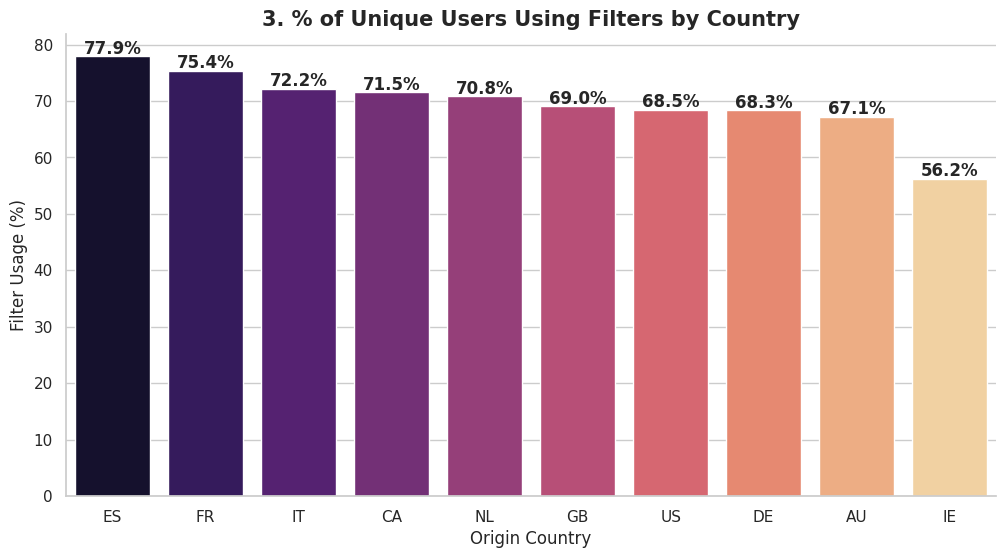

,origin_country,Total_Users,Users_Who_Filtered,Filter_Usage_Pct
3,ES,838,653,77.92
4,FR,1853,1397,75.39
7,IT,1065,769,72.21
1,CA,569,407,71.53
8,NL,473,335,70.82
5,GB,2578,1780,69.05
9,US,3246,2222,68.45
2,DE,1153,788,68.34
0,AU,496,333,67.14
6,IE,3225,1812,56.19


In [23]:
# 1. יצירת טבלת התנהגות ברמת משתמש
# אנחנו בודקים האם המשתמש השתמש בפילטר (used_any_filter) לפחות פעם אחת
user_behavior = oct_searches[oct_searches['origin_country'].isin(top_countries)].groupby(['origin_country', 'id_user']).agg(
    used_filter=('used_any_filter', 'max') # לוקח 1 אם המשתמש השתמש בפילטר לפחות פעם אחת, אחרת 0
).reset_index()

# 2. אגרגציה לפי מדינה לחישוב אחוז המשתמשים שנעזרו בפילטרים
geo_filters = user_behavior.groupby('origin_country').agg(
    Total_Users=('id_user', 'count'),
    Users_Who_Filtered=('used_filter', 'sum')
).reset_index()

# חישוב האחוז
geo_filters['Filter_Usage_Pct'] = (geo_filters['Users_Who_Filtered'] / geo_filters['Total_Users']) * 100
geo_filters = geo_filters.sort_values('Filter_Usage_Pct', ascending=False)

# 3. ויזואליזציה
plt.figure(figsize=(12, 6))
sns.barplot(
    data=geo_filters,
    x='origin_country',
    y='Filter_Usage_Pct',
    hue='origin_country',
    palette='magma',
    legend=False
)

plt.title('3. % of Unique Users Using Filters by Country', fontsize=15, fontweight='bold')
plt.ylabel('Filter Usage (%)')
plt.xlabel('Origin Country')

# הוספת אחוזים מעל העמודות
for i, v in enumerate(geo_filters['Filter_Usage_Pct']):
    plt.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

sns.despine()
plt.show()

# הצגת הנתונים הגולמיים לסיכום
display(geo_filters.round(2))

<div dir="rtl">

### **📊 סיכום ממצאים: שלב ג' - שימוש בפילטרים (Behavioral Depth)**

ניתוח הרגלי השימוש בפילטרים יכול להסביר את אחוזי ההמרה:

* **מתאם ישיר בין דיוק להמרה:** המדינות שמובילות בשימוש בפילטרים – ספרד (**ES**), צרפת (**FR**) ואיטליה (**IT**) – הן בדיוק המדינות שראינו בשלב ב' כבעלות אחוזי ההמרה הגבוהים ביותר (סביב 70-78% שימוש בפילטרים).
* **הפיצוח של אירלנד (IE):** כעת ברור מדוע אירלנד מדשדשת בהמרות למרות נפח החיפושים האדיר. היא מציגה את **אחוז השימוש הנמוך ביותר בפילטרים (56.2%)**. המשתמשים האיריים מבצעים חיפושים רחבים וגנריים, "טובעים" בתוצאות לא רלוונטיות, ולכן מתעייפים מבלי להמיר.
* **המשתמש הממוקד:** נראה שמשתמשים מצרפת ואיטליה מגיעים לאתר עם כוונת רכישה גבוהה יותר או הבנה טובה יותר של הממשק, מה שמאפשר להם לסנן תוצאות ולהגיע לדירה המתאימה במהירות.

</div>

<div dir="rtl">

## **שלב ד': ניתוח המרה להזמנה סופית (Final Booking Performance)**

בשלב זה אנו בודקים את ה"שורה התחתונה". לא כל יצירת קשר מסתיימת בהזמנה, והפער הזה יכול לנבוע מסיבות שונות: חוסר זמינות של מארחים, מחיר סופי גבוה מדי, או היסוס של הרגע האחרון.

**שאלות המפתח:**
* איזו מדינה מייצרת את כמות ההזמנות (Bookings) הגדולה ביותר?
* **Contact-to-Booking Gap:** האם מדינות עם אחוז יצירת קשר גבוה (כמו איטליה וצרפת) מצליחות גם לסגור את ההזמנות בפועל?
* האם יש מדינות שבהן יש "איבוד" משמעותי של לקוחות בין שלב ההודעה לשלב התשלום?

</div>

<Figure size 1200x600 with 0 Axes>

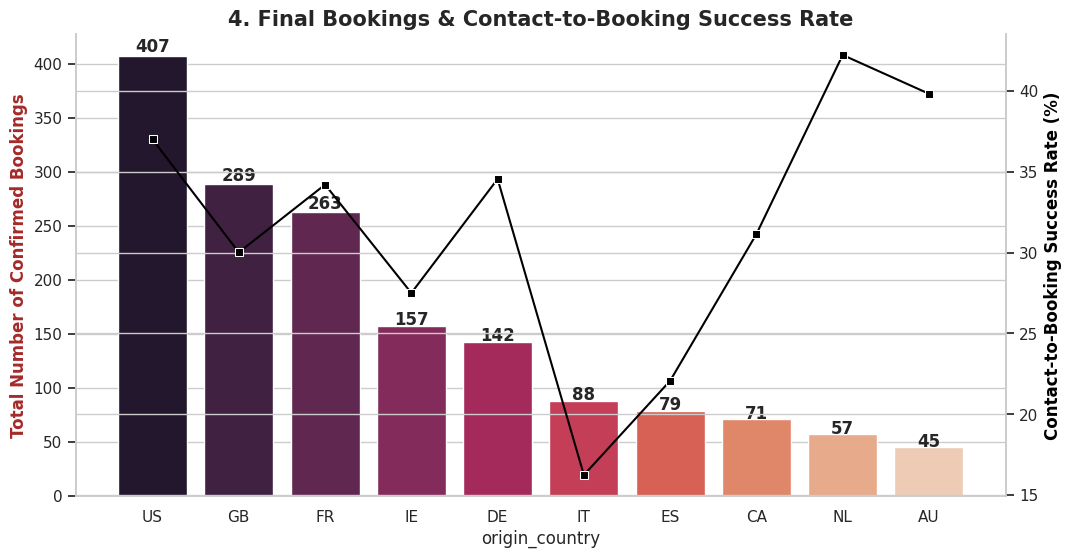

,origin_country,Total_Contacts,Final_Bookings,Contact_to_Booking_Pct
9,US,1100,407,37.00
5,GB,963,289,30.01
4,FR,769,263,34.20
6,IE,571,157,27.50
2,DE,411,142,34.55
7,IT,542,88,16.24
3,ES,358,79,22.07
1,CA,228,71,31.14
8,NL,135,57,42.22
0,AU,113,45,39.82


In [26]:
import pandas as pd

# 1. הכנת הנתונים: חיבור מדינת המקור מטבלת החיפושים לטבלת הפניות
# אנחנו יוצרים מיפוי של id_user למדינה כדי להדביק אותו לפניות
user_country_map = oct_searches[['id_user', 'origin_country']].drop_duplicates()

# חיבור המדינה לטבלת ה-contacts (נשתמש ב-id_guest כי הוא ה-id_user שפנה)
if 'origin_country' not in oct_contacts.columns:
    oct_contacts = oct_contacts.merge(
        user_country_map,
        left_on='id_guest',
        right_on='id_user',
        how='left'
    )

# 2. אגרגציה לפי מדינה - ניתוח הזמנות סופיות
geo_final_performance = oct_contacts[oct_contacts['origin_country'].isin(top_countries)].groupby('origin_country').agg(
    Total_Contacts=('id_guest', 'count'),
    Final_Bookings=('is_booked', 'sum')
).reset_index()

# חישוב אחוז ההמרה מהודעה להזמנה (Success Rate)
geo_final_performance['Contact_to_Booking_Pct'] = (geo_final_performance['Final_Bookings'] / geo_final_performance['Total_Contacts']) * 100

# מיון לפי כמות הזמנות
geo_final_performance = geo_final_performance.sort_values('Final_Bookings', ascending=False)

# 3. ויזואליזציה
plt.figure(figsize=(12, 6))
fig, ax1 = plt.subplots(figsize=(12, 6))

sns.barplot(data=geo_final_performance, x='origin_country', y='Final_Bookings', hue='origin_country', palette='rocket', ax=ax1, legend=False)
ax1.set_title('4. Final Bookings & Contact-to-Booking Success Rate', fontsize=15, fontweight='bold')
ax1.set_ylabel('Total Number of Confirmed Bookings', color='brown', fontweight='bold')

ax2 = ax1.twinx()
sns.lineplot(data=geo_final_performance, x='origin_country', y='Contact_to_Booking_Pct', color='black', marker='s', ax=ax2)
ax2.set_ylabel('Contact-to-Booking Success Rate (%)', color='black', fontweight='bold')

for i, v in enumerate(geo_final_performance['Final_Bookings']):
    ax1.text(i, v + (v*0.01), f'{int(v)}', ha='center', fontweight='bold')

sns.despine(right=False)
plt.show()

display(geo_final_performance.round(2))

<div dir="rtl">

### **📊 סיכום ממצאים: שלב ד' - המרה להזמנה סופית (Final Booking)**

השלב הזה הוא ה"רגע של אמת" שבו אנחנו רואים כמה מהפניות הפכו לכסף. התוצאות חושפות פערים מרתקים בין מדינות:

* **ארה"ב (US) שומרת על הכתר:** לא רק שהיא מביאה הכי הרבה משתמשים, היא גם המדינה עם כמות ההזמנות הסופיות הגבוהה ביותר (**407**) ואחוז המרה סולידי של **37%** מהודעה להזמנה.
* **ההפתעה של הולנד (NL) ואוסטרליה (AU):** למרות שהן קטנות בנפח, הן המדינות הכי "תכליתיות". מי ששולח שם הודעה, סוגר עסקה בשיעור הגבוה ביותר (**42.2%** ו-**39.8%** בהתאמה).
* **"הבור האיטלקי" (IT) - תובנה קריטית:** זוכר שבשלב ב' איטליה הייתה שיאנית ההמרה ליצירת קשר? כאן אנחנו רואים קריסה – רק **16.2%** מהפניות הופכות להזמנה.
    * *משמעות:* האיטלקים מאוד רוצים להזמין (יוצרים קשר), אבל משהו משתבש בדרך. אולי המארחים באיטליה לא מאשרים, אולי המחיר הסופי שונה, או שיש בעיית אמון.
* **צרפת (FR) וגרמניה (DE):** מציגות ביצועים עקביים וטובים מאוד (סביב **34%** המרה). אלו שווקים "בריאים" שבהם כל שלבי המשפך עובדים היטב.

</div>

--------------------------------------------------------------------------------

<div dir="rtl">

## **4. ניתוח התאמת מלאי לפי גודל קבוצה (Inventory Fit)**

לאחר שמיפינו את הביצועים הגיאוגרפיים, אנו עוברים לבחון את **היצע הדירות** שלנו אל מול **דרישות המשתמשים**. המטרה היא להבין האם הפלטפורמה מספקת מענה טוב לכל סוגי ההרכבים (מיחידים ועד קבוצות גדולות).

### **מה אנחנו בודקים?**
בשלב זה חילקנו את החיפושים ל"סלים" (Buckets) לפי מספר האורחים המבוקש (`n_guests_min`). חלוקה זו מאפשרת לנו לזהות פערים במלאי:
* **יחידים וזוגות (1-2 אורחים):** קהל שבדרך כלל מחפש חדרים או דירות סטודיו.
* **משפחות וקבוצות קטנות (3-6 אורחים):** קהל שזקוק לדירות עם מספר חדרי שינה.
* **קבוצות גדולות (7+ אורחים):** קהל יעד ממוקד מאוד שזקוק לנכסים גדולים במיוחד.

### **שאלות המפתח לחקירה:**
1.  **זיהוי "צווארי בקבוק" במלאי:** האם יש קבוצות גודל שבהן אחוז ההמרה נמוך משמעותית מהממוצע? (סימן למחסור בנכסים מתאימים או מחירים לא תחרותיים).
2.  **יעילות המרה:** האם המערכת יודעת להציע תוצאות רלוונטיות באותה מידה למטייל בודד ולמשפחה מרובת ילדים?
3.  **הזדמנויות עסקיות:** האם כדאי להשקיע מאמץ בגיוס מארחים עם נכסים גדולים (7+), או שדווקא שם נמצא פוטנציאל הצמיחה הגדול ביותר?

</div>

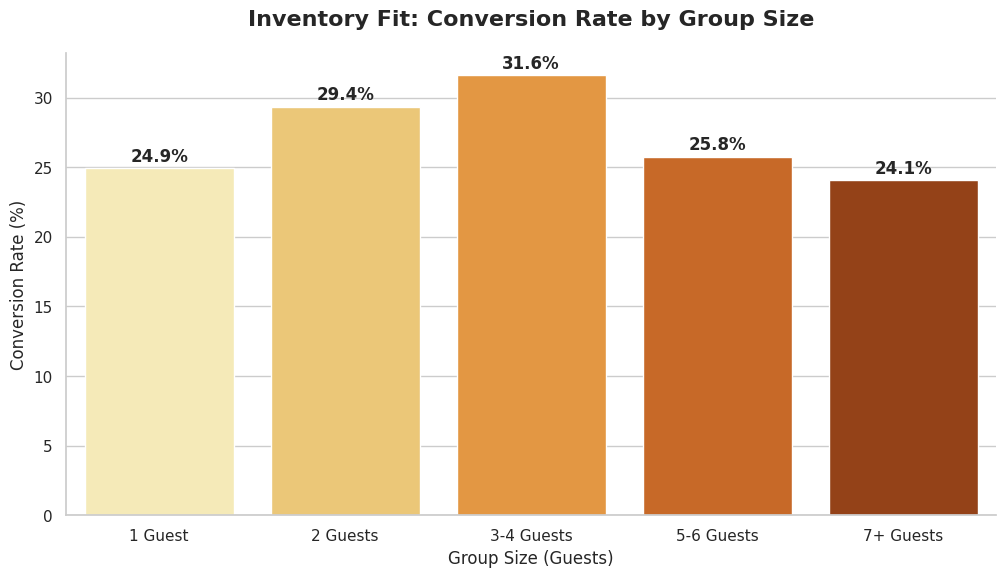

,guest_bucket,Total_Searches,Converted_Searches,Conversion_Rate_Pct
0,1 Guest,22573,5626,24.92
1,2 Guests,8001,2349,29.36
2,3-4 Guests,3455,1092,31.61
3,5-6 Guests,1110,286,25.77
4,7+ Guests,598,144,24.08


In [30]:
# 1. הגדרת שם העמודה וחלוקה לבאקטים
guest_col = 'n_guests_min'

# יצירת הבאקטים
oct_searches['guest_bucket'] = pd.cut(oct_searches[guest_col],
                                     bins=[0, 1, 2, 4, 6, 20],
                                     labels=['1 Guest', '2 Guests', '3-4 Guests', '5-6 Guests', '7+ Guests'])

# 2. אגרגציה - שימוש ב-agg בצורה קריאה
# הערה: observed=True חשוב בגרסאות חדשות כשעובדים עם Categorical data
inventory_stats = oct_searches.groupby('guest_bucket', observed=True).agg(
    Total_Searches=('is_converted_session', 'count'),
    Converted_Searches=('is_converted_session', 'sum'),
    Conversion_Rate_Pct=('is_converted_session', 'mean')
).reset_index()

# הפיכה לאחוזים
inventory_stats['Conversion_Rate_Pct'] = inventory_stats['Conversion_Rate_Pct'] * 100

# 3. ויזואליזציה
plt.figure(figsize=(12, 6))
sns.barplot(data=inventory_stats,
            x='guest_bucket',
            y='Conversion_Rate_Pct',
            hue='guest_bucket', # מניעת אזהרה
            palette='YlOrBr',
            legend=False)

plt.title('Inventory Fit: Conversion Rate by Group Size', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Conversion Rate (%)')
plt.xlabel('Group Size (Guests)')

# הוספת אחוזים מעל הברים
for i, v in enumerate(inventory_stats['Conversion_Rate_Pct']):
    plt.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

sns.despine()
plt.show()

# 4. הצגת נתונים
display(inventory_stats.round(2))

<div dir="rtl">

### **🔍 תובנות מרכזיות - ניתוח התאמת מלאי**

* **התאמה אופטימלית:** המערכת בשיאה עבור קבוצות של **2 עד 4 אורחים** (ממוצע המרה של כ-30%). זהו גרעין הפעילות המרכזי והרווחי ביותר.
* **הזדמנות לצמיחה (Large Groups):** קיים ביקוש משמעותי לקבוצות של 5 אורחים ומעלה, אך אחוזי ההמרה נמוכים יותר. גיוס נכסים גדולים (3-4 חדרי שינה) עשוי להקפיץ את המכירות בסגמנט זה.
* **חשיבה מחדש על יחידים:** למרות נפח החיפושים הגבוה ביותר (22.5 אלף חיפושים!), יחידים ממירים פחות מזוגות. כדאי לבדוק האם המלאי הנוכחי "יקר" מדי עבור מטייל בודד.

</div>

<div dir="rtl">

## **שלב 5א: ניתוח הגורם האנושי - השפעת כמות ההודעות על הסגירה**

לאחר שבחנו את המלאי, אנו עוברים לבחון את **הדינמיקה בין המארח לאורח**. בניתוח זה נבדוק האם קיים קשר בין כמות ההודעות שהוחלפו בשרשור (Thread) לבין הסיכוי שהפנייה תהפוך להזמנה סופית.

**השערות המחקר:**
* **מעט הודעות (1-2):** עשוי להעיד על "Instant Booking" או אורח החלטי ומארח זמין, אך גם על פניות קרות שננטשו מהר.
* **כמות בינונית (3-10):** דיאלוג בריא שבו האורח שואל שאלות והמארח עונה, מה שבונה אמון.
* **הרבה הודעות (11+):** עשוי להעיד על "פינג-פונג" מתיש, חוסר הבנה או קשיים בתהליך האישור שעלולים להוביל לנטישה.

**מה אנחנו מחפשים?**
אנחנו מחפשים את ה-**Sweet Spot**: כמות ההודעות האופטימלית שמובילה לאחוז הסגירה הגבוה ביותר.

</div>

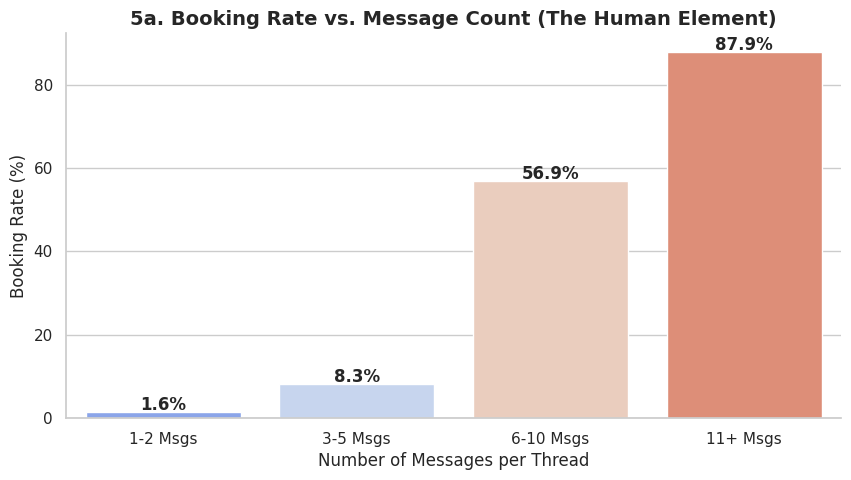

,msg_bucket,Total_Inquiries,Total_Bookings,Booking_Rate_Pct
0,1-2 Msgs,1565,25,1.60
1,3-5 Msgs,2537,210,8.28
2,6-10 Msgs,1251,712,56.91
3,11+ Msgs,1108,974,87.91


In [32]:
# 1. יצירת באקטים לכמות הודעות
oct_contacts['msg_bucket'] = pd.cut(oct_contacts['n_messages'],
                                   bins=[-1, 2, 5, 10, 500],
                                   labels=['1-2 Msgs', '3-5 Msgs', '6-10 Msgs', '11+ Msgs'])

# 2. אגרגציה - חישוב אחוז סגירה
human_msg_stats = oct_contacts.groupby('msg_bucket', observed=True).agg(
    Total_Inquiries=('is_booked', 'count'),
    Total_Bookings=('is_booked', 'sum'),
    Booking_Rate_Pct=('is_booked', 'mean')
).reset_index()

# הפיכה לאחוזים
human_msg_stats['Booking_Rate_Pct'] = human_msg_stats['Booking_Rate_Pct'] * 100

# 3. ויזואליזציה
plt.figure(figsize=(10, 5))
sns.barplot(data=human_msg_stats, x='msg_bucket', y='Booking_Rate_Pct',
            hue='msg_bucket', palette='coolwarm', legend=False)

plt.title('5a. Booking Rate vs. Message Count (The Human Element)', fontsize=14, fontweight='bold')
plt.ylabel('Booking Rate (%)')
plt.xlabel('Number of Messages per Thread')

for i, v in enumerate(human_msg_stats['Booking_Rate_Pct']):
    plt.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

sns.despine()
plt.show()

display(human_msg_stats.round(2))

<div dir="rtl">

### **🔍 תובנות מרכזיות - ניתוח אינטראקציה (שלב 5א)**

* **היכן רוב המאמץ מתבזבז?** הסגמנט של **3-5 הודעות** מרכז את נפח הפניות הגבוה ביותר (2,537), אך מניב רק 210 הזמנות. זהו שלב שבו שיחות רבות "מתות" ללא סגירה.
* **הוכחת האמון:** ברגע ששיחה עוברת את רף 5 ההודעות, אחוז הסגירה קופץ מ-8% ל-57%. זהו מדד מובהק לכך שבפלטפורמה הזו, תקשורת מעמיקה היא המפתח לסגירת עסקה.
* **המנוע הכלכלי:** קבוצת ה-**11+ הודעות** היא היעילה ביותר. למרות שהיא מייצגת רק כ-17% מהפניות, היא אחראית על כ-50% מכלל ההזמנות שנסגרו (974 מתוך 1,921).

</div>

<div dir="rtl">

## **שלב 5ב: ניתוח הגורם האנושי - מהירות תגובה מול סגירת עסקה**

לאחר שראינו ששיח מעמיק (6+ הודעות) מוביל לאחוזי סגירה פנומנליים, עלינו לבחון את הגורם המכריע השני בדינמיקה הזו: **זמן.** בעולם של "כאן ועכשיו", מהירות התגובה של המארח היא לעיתים ההבדל בין אורח שמרגיש ביטחון לבין אורח שממשיך לחפש בנכס אחר.

**השאלות שעל הפרק:**
* האם תגובה ב-15 הדקות הראשונות ("זמן אמת") מעלה משמעותית את הסיכוי לסגירה?
* מהו "זמן הזהב" שמעבר לו הסיכוי לסגור עסקה צונח?
* האם יש קבוצת מארחים שזקוקה לשיפור משמעותי במהירות התגובה כדי למנוע נטישת לקוחות?

</div>

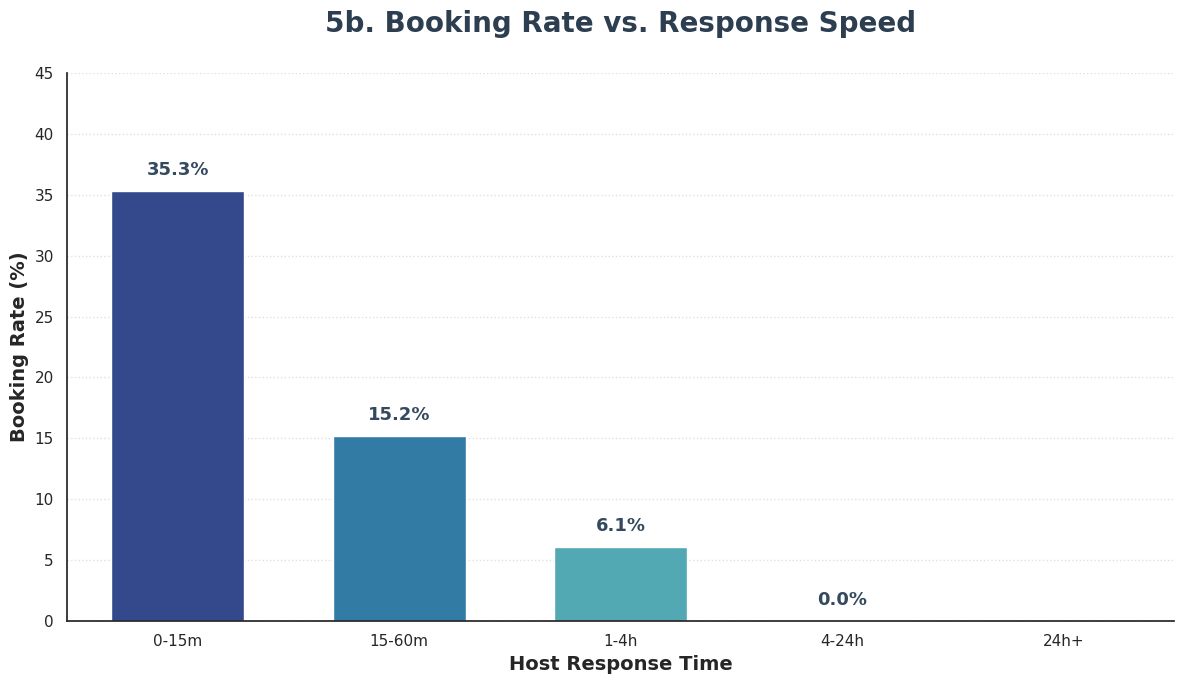


📊 טבלת סיכום: השפעת זמן התגובה על אחוז הסגירה


,זמן תגובה,סך פניות,סך הזמנות,אחוז סגירה (%)
0,0-15m,5111,1804,35.30
1,15-60m,719,109,15.16
2,1-4h,132,8,6.06
3,4-24h,11,0,0.00


In [39]:
# 1. הגדרות סגנון
sns.set_theme(style="white")
plt.figure(figsize=(12, 7))

# 2. יצירת הגרף - רחב וממורכז (dodge=False)
ax = sns.barplot(
    data=human_reply_stats,
    x='reply_bucket',
    y='Booking_Rate_Pct',
    hue='reply_bucket',
    palette='YlGnBu_r',
    legend=False,
    dodge=False,
    width=0.6
)

# 3. עיצוב כותרות וצירים
plt.title('5b. Booking Rate vs. Response Speed\n', fontsize=20, fontweight='bold', color='#2c3e50')
plt.ylabel('Booking Rate (%)', fontsize=14, fontweight='semibold')
plt.xlabel('Host Response Time', fontsize=14, fontweight='semibold')
plt.ylim(0, 45)

# 4. הוספת אחוזים מעל הברים
for p in ax.patches:
    height = p.get_height()
    label_y = height + 1 if height > 0 else 1
    ax.text(
        p.get_x() + p.get_width() / 2.,
        label_y,
        f'{height:.1f}%',
        ha='center', va='bottom',
        fontsize=13, fontweight='bold', color='#34495e'
    )

# 5. ליטוש סופי של הגרף
sns.despine()
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# 6. הצגת טבלת נתונים מעוצבת מתחת לגרף
print("\n" + "="*50)
print("📊 טבלת סיכום: השפעת זמן התגובה על אחוז הסגירה")
print("="*50)

# עיצוב הטבלה להצגה נקייה ב-Colab
styled_table = human_reply_stats.rename(columns={
    'reply_bucket': 'זמן תגובה',
    'Total_Inquiries': 'סך פניות',
    'Total_Bookings': 'סך הזמנות',
    'Booking_Rate_Pct': 'אחוז סגירה (%)'
})

display(styled_table.round(2))

<div dir="rtl">

### **🔍 תובנות מרכזיות - ניתוח מהירות תגובה**

* **חוק ה-15 דקות:** המהירות היא הגורם המכריע ביותר לסגירה. תגובה ב-15 הדקות הראשונות מייצרת אחוז סגירה הגבוה פי 6 מאשר תגובה אחרי שעה.
* **איבוד רלוונטיות מהיר:** הפלטפורמה חווה "נטישה קלינית" של פניות לאחר 4 שעות. כמעט אף פנייה שנענתה באיחור כזה לא הבשילה לכדי הזמנה.
* **המלצה אופרטיבית:** אומנם רוב המארחים כבר מיישמים מענה מהיר (85%),  אבל יש גם כאלו שלא לכן יש להטמיע מערכת התראות (Push Notifications) למארחים ולתמרץ אותם לענות בטווח של "זמן הזהב". מארח שעונה מהר הוא מארח שסוגר.

</div>